> (중요) 여러분 구글 드라이브에 최소 7GB 이상은 확보되어 있어야 합니다!

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import unicodedata  # 0번 섹션에 추가 필요

# 📌 경로 설정 (제공해주신 경로 반영)
def normalize_path(path):
    # 1. unicodedata.normalize('NFC', path): 경로 문자열을 NFC 방식으로 통일
    # 2. .strip(): 앞뒤에 붙은 불필요한 공백 제거
    return unicodedata.normalize('NFC', path).strip()

In [33]:
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)

CompletedProcess(args=['apt-get', 'install', '-y', 'fonts-nanum'], returncode=0, stdout=b'Reading package lists...\nBuilding dependency tree...\nReading state information...\nThe following NEW packages will be installed:\n  fonts-nanum\n0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.\nNeed to get 10.3 MB of archives.\nAfter this operation, 34.1 MB of additional disk space will be used.\nGet:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]\nFetched 10.3 MB in 2s (5,035 kB/s)\nSelecting previously unselected package fonts-nanum.\r\n(Reading database ... \r(Reading database ... 5%\r(Reading database ... 10%\r(Reading database ... 15%\r(Reading database ... 20%\r(Reading database ... 25%\r(Reading database ... 30%\r(Reading database ... 35%\r(Reading database ... 40%\r(Reading database ... 45%\r(Reading database ... 50%\r(Reading database ... 55%\r(Reading database ... 60%\r(Reading database ... 65%\r(Reading database ... 70%\r(Re

#### `normalize_path`는?

`normalize_path`는 파일 경로에 포함된 **한글(유니코드) 처리 방식**을 통일하여, 경로를 찾지 못하는 에러를 방지하기 위한 함수입니다.

특히 **Google Colab**이나 **Mac, Windows** 사이에서 데이터를 주고받을 때 한글 폴더명이 깨져서 발생하는 `File Not Found` 에러를 잡는 데 필수적입니다.

<br>

##### 왜 사용하나요? (NFC vs NFD)

한글을 컴퓨터가 인식하는 방식은 크게 두 가지입니다.

* **NFC (Windows 스타일):** '강'을 '강'이라는 하나의 글자로 저장합니다.
* **NFD (Mac/Unix 스타일):** '강'을 'ㄱ', 'ㅏ', 'ㅇ'으로 쪼개서 저장합니다.

사람 눈에는 똑같이 "초급 프로젝트"라고 보이지만, 컴퓨터 입장에서는 글자 조합 방식이 다르면 **완전히 다른 경로**로 인식합니다. `normalize_path` 는 이를 **NFC(표준 방식)** 로 강제 통일해주는 역할을 합니다.

In [4]:
import os
import json
import pandas as pd
from PIL import Image
import unicodedata  # 0번 섹션에 추가 필요
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torchvision.transforms import v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

In [4]:
extract_path = normalize_path("/content/drive/MyDrive/data/초급_프로젝트/dataset/") # unzipped folder

TRAIN_JSON_PATH = os.path.join(extract_path, "merged_annotations_train_final.json")
TEST_JSON_PATH = os.path.join(extract_path, "merged_annotations_test_final.json")
TRAIN_IMG_DIR = os.path.join(extract_path, "train_images")
TEST_IMG_DIR  = os.path.join(extract_path, "test_images")

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
import json
import pandas as pd
from PIL import Image

In [7]:
with open(TRAIN_JSON_PATH, 'r') as f:
    train_data = json.load(f)

In [8]:
with open(TEST_JSON_PATH, 'r') as f:
    test_data = json.load(f)

In [10]:
print(json.dumps(train_data, indent=4, ensure_ascii=False))

{
    "images": [
        {
            "file_name": "K-001900-016551-024850-027926_0_2_0_2_90_000_200.png",
            "width": 976,
            "height": 1280,
            "imgfile": "K-001900-016551-024850-027926_0_2_0_2_90_000_200.png",
            "drug_N": "K-001900",
            "drug_S": "정상알약",
            "back_color": "연회색 배경",
            "drug_dir": "앞면",
            "light_color": "주백색",
            "camera_la": 90,
            "camera_lo": 0,
            "size": 200,
            "dl_idx": "1899",
            "dl_mapping_code": "K-001900",
            "dl_name": "보령부스파정 5mg",
            "dl_name_en": "Buspar Tab. 5mg Boryung",
            "img_key": "http://connectdi.com/design/img/drug/1Mxwka5v0lL.jpg",
            "dl_material": "부스피론염산염",
            "dl_material_en": "Buspirone Hydrochloride",
            "dl_custom_shape": "정제, 저작정",
            "dl_company": "보령제약(주)",
            "dl_company_en": "Boryung",
            "di_company_mf": "",
            "di_company

In [10]:
print(list(train_data))

['images', 'annotations', 'categories']


In [12]:
for img in train_data["images"][:3]:
    print(img)

{'file_name': 'K-001900-016551-024850-027926_0_2_0_2_90_000_200.png', 'width': 976, 'height': 1280, 'imgfile': 'K-001900-016551-024850-027926_0_2_0_2_90_000_200.png', 'drug_N': 'K-001900', 'drug_S': '정상알약', 'back_color': '연회색 배경', 'drug_dir': '앞면', 'light_color': '주백색', 'camera_la': 90, 'camera_lo': 0, 'size': 200, 'dl_idx': '1899', 'dl_mapping_code': 'K-001900', 'dl_name': '보령부스파정 5mg', 'dl_name_en': 'Buspar Tab. 5mg Boryung', 'img_key': 'http://connectdi.com/design/img/drug/1Mxwka5v0lL.jpg', 'dl_material': '부스피론염산염', 'dl_material_en': 'Buspirone Hydrochloride', 'dl_custom_shape': '정제, 저작정', 'dl_company': '보령제약(주)', 'dl_company_en': 'Boryung', 'di_company_mf': '', 'di_company_mf_en': '', 'item_seq': 198700706, 'di_item_permit_date': '19870323', 'di_class_no': '[01170]정신신경용제', 'di_etc_otc_code': '전문의약품', 'di_edi_code': '641901280,A09302381', 'chart': '이약은 양면볼록한 장방형의 흰색정제이다', 'drug_shape': '장방형', 'thick': 2.5, 'leng_long': 8, 'leng_short': 4.5, 'print_front': 'BSP', 'print_back': '5', '

In [11]:
for ann in train_data["annotations"][:3]:
    print(ann)

{'area': 25654, 'iscrowd': 0, 'bbox': [158, 251, 202, 127], 'category_id': 1899, 'ignore': 0, 'segmentation': [], 'id': 1, 'image_id': 1}
{'area': 27930, 'iscrowd': 0, 'bbox': [631, 893, 210, 133], 'category_id': 1899, 'ignore': 0, 'segmentation': [], 'id': 2, 'image_id': 2}
{'area': 25600, 'iscrowd': 0, 'bbox': [143, 242, 200, 128], 'category_id': 1899, 'ignore': 0, 'segmentation': [], 'id': 3, 'image_id': 3}


In [13]:
for cat in train_data["categories"]:
    print(cat)

{'supercategory': 'pill', 'id': 1899, 'name': '보령부스파정 5mg'}
{'supercategory': 'pill', 'id': 27925, 'name': '울트라셋이알서방정'}
{'supercategory': 'pill', 'id': 16550, 'name': '동아가바펜틴정 800mg'}
{'supercategory': 'pill', 'id': 24849, 'name': '놀텍정 10mg'}
{'supercategory': 'pill', 'id': 29344, 'name': '비모보정 500/20mg'}
{'supercategory': 'pill', 'id': 27652, 'name': '세비카정 10/40mg'}
{'supercategory': 'pill', 'id': 3482, 'name': '기넥신에프정(은행엽엑스)(수출용)'}
{'supercategory': 'pill', 'id': 22346, 'name': '자누비아정 50mg'}
{'supercategory': 'pill', 'id': 20237, 'name': '플라빅스정 75mg'}
{'supercategory': 'pill', 'id': 21770, 'name': '라비에트정 20mg'}
{'supercategory': 'pill', 'id': 16547, 'name': '가바토파정 100mg'}
{'supercategory': 'pill', 'id': 29450, 'name': '레일라정'}
{'supercategory': 'pill', 'id': 33879, 'name': '글리틴정(콜린알포세레이트)'}
{'supercategory': 'pill', 'id': 16231, 'name': '리피토정 20mg'}
{'supercategory': 'pill', 'id': 3350, 'name': '일양하이트린정 2mg'}
{'supercategory': 'pill', 'id': 35205, 'name': '아토젯정 10/40mg'}
{'supercatego

In [14]:
print(f"the number of imgs: {len(train_data['images'])}")
print(f"the number of anns: {len(train_data['annotations'])}")
print(f"the number of cats: {len(train_data['categories'])}")

the number of imgs: 1489
the number of anns: 4526
the number of cats: 73


In [15]:
print(f"the number of imgs: {len(test_data['images'])}")
print(f"the number of anns: {len(test_data['annotations'])}")
print(f"the number of cats: {len(test_data['categories'])}")

the number of imgs: 843
the number of anns: 1129
the number of cats: 73


In [9]:
df_ann = pd.DataFrame(train_data["annotations"])
df_img = pd.DataFrame(train_data["images"])
df_cat = pd.DataFrame(train_data["categories"])


In [17]:
print(df_ann.isnull().sum())
print(df_img.isnull().sum())
print(df_cat.isnull().sum())

area            0
iscrowd         0
bbox            0
category_id     0
ignore          0
segmentation    0
id              0
image_id        0
dtype: int64
file_name                0
width                    0
height                   0
imgfile                  0
drug_N                   0
drug_S                   0
back_color               0
drug_dir                 0
light_color              0
camera_la                0
camera_lo                0
size                     0
dl_idx                   0
dl_mapping_code          0
dl_name                  0
dl_name_en               0
img_key                 55
dl_material              0
dl_material_en           0
dl_custom_shape          0
dl_company               0
dl_company_en            0
di_company_mf            0
di_company_mf_en         0
item_seq                 0
di_item_permit_date      0
di_class_no              0
di_etc_otc_code          0
di_edi_code              0
chart                   55
drug_shape              55
thick 

In [15]:
invalid_bbox = df_ann[df_ann["bbox"].apply(lambda x: x is None or len(x) != 4)]
print(f"\n비정상 bbox 수: {len(invalid_bbox)}")
print(invalid_bbox)


비정상 bbox 수: 0
Empty DataFrame
Columns: [area, iscrowd, bbox, category_id, ignore, segmentation, id, image_id]
Index: []


In [16]:
valid_ids = set(df_img["id"])
missing = df_ann[~df_ann["image_id"].isin(valid_ids)]
print(f"\nimages에 없는 image_id 수: {len(missing)}")


images에 없는 image_id 수: 0


In [10]:
def build_df_from_merged_json(json_path, img_dir):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # 1) 이미지 정보 매핑 (id -> file_name)
    id_to_fname = {img["id"]: img["file_name"] for img in data["images"]}

    records = []
    # 2) 어노테이션 순회
    for ann in data["annotations"]:
        img_id_coco = ann["image_id"]
        file_name = id_to_fname.get(img_id_coco)
        
        if file_name is None: continue
        
        img_path = os.path.join(img_dir, file_name)
        
        # 실제 이미지 파일이 있는지 확인 (선택 사항이지만 안전함)
        if not os.path.exists(img_path):
            continue

        x, y, w, h = ann["bbox"]
        
        records.append({
            "image_path": img_path,
            "image_id": os.path.splitext(file_name)[0], # 파일명을 ID로 사용
            "category_id": int(ann["category_id"]),
            "bbox_x": float(x),
            "bbox_y": float(y),
            "bbox_w": float(w),
            "bbox_h": float(h),
        })

    return pd.DataFrame(records)

# 실행
df = build_df_from_merged_json(TRAIN_JSON_PATH, TRAIN_IMG_DIR)
print(f"✅ 학습 데이터 로드 완료: {len(df)} 개의 객체 탐지됨")

✅ 학습 데이터 로드 완료: 4526 개의 객체 탐지됨


In [12]:
df["category_id"]

,category_id
0,1899
1,1899
2,1899
3,27925
4,16550
...,...
4521,3350
4522,3350
4523,38161
4524,38161


In [13]:
# sorting cat_id 
unique_cats = sorted(df["category_id"].unique())
print("고유 category_id 개수:", len(unique_cats))


고유 category_id 개수: 73


In [19]:
orig2model = { cid: i + 1 for i, cid in enumerate(unique_cats)}  # org → model (for train)
model2orig = {v: k for k, v in orig2model.items()}               # model → org (for test)
num_classes = len(unique_cats) + 1  # background 포함
print("num_classes (background 포함):", num_classes)

num_classes (background 포함): 74


In [16]:
orig2model, model2orig

({np.int64(1899): 1,
  np.int64(2482): 2,
  np.int64(3350): 3,
  np.int64(3482): 4,
  np.int64(3543): 5,
  np.int64(3742): 6,
  np.int64(3831): 7,
  np.int64(4377): 8,
  np.int64(4542): 9,
  np.int64(5093): 10,
  np.int64(5885): 11,
  np.int64(6191): 12,
  np.int64(6562): 13,
  np.int64(10220): 14,
  np.int64(12080): 15,
  np.int64(12246): 16,
  np.int64(12419): 17,
  np.int64(12777): 18,
  np.int64(13394): 19,
  np.int64(13899): 20,
  np.int64(16231): 21,
  np.int64(16261): 22,
  np.int64(16547): 23,
  np.int64(16550): 24,
  np.int64(16687): 25,
  np.int64(18109): 26,
  np.int64(18146): 27,
  np.int64(18356): 28,
  np.int64(19231): 29,
  np.int64(19551): 30,
  np.int64(19606): 31,
  np.int64(19860): 32,
  np.int64(20013): 33,
  np.int64(20237): 34,
  np.int64(20876): 35,
  np.int64(21025): 36,
  np.int64(21324): 37,
  np.int64(21770): 38,
  np.int64(22073): 39,
  np.int64(22346): 40,
  np.int64(22361): 41,
  np.int64(22626): 42,
  np.int64(23202): 43,
  np.int64(23222): 44,
  np.int64

In [ ]:
# class OralDrugDataset(Dataset):
#     """
#     Faster R-CNN용 Dataset
#     - __getitem__은 (image, target) 반환
#     - image: [C,H,W] float tensor
#     - target: dict(boxes, labels, image_id, ...)
#     """
#     def __init__(self, df, orig2model, transforms=None):
#         self.df = df.reset_index(drop=True)
#         self.orig2model = orig2model
#         self.transforms = transforms
#         self.image_ids = self.df["image_id"].unique().tolist() # id grouping

#     def __len__(self):
#         return len(self.image_ids)

#     def __getitem__(self, idx):
#         # 1) image_id 선택
#         image_id = self.image_ids[idx]

#         # 2) 해당 image_id에 해당하는 모든 row (여러 객체) 가져오기
#         df_img = self.df[self.df["image_id"] == image_id]

#         # 3) 이미지 로드
#         img_path = df_img["image_path"].iloc[0]
#         image = Image.open(img_path).convert("RGB")

#         # 4) bbox / labels 구성
#         boxes = []
#         labels = []

#         for _, row in df_img.iterrows():
#             x = row["bbox_x"]
#             y = row["bbox_y"]
#             w = row["bbox_w"]
#             h = row["bbox_h"]

#             # [x1, y1, x2, y2] 형식으로 변환
#             x1 = x
#             y1 = y
#             x2 = x + w
#             y2 = y + h
#             boxes.append([x1, y1, x2, y2])

#             # 원본 category_id → 모델용 label로 변환
#             orig_cat = int(row["category_id"])
#             model_cat = self.orig2model[orig_cat]
#             labels.append(model_cat)

#         boxes = torch.tensor(boxes, dtype=torch.float32)
#         labels = torch.tensor(labels, dtype=torch.int64)

#         target = {
#             "boxes": boxes,
#             "labels": labels,
#             # image_id는 loss에는 크게 영향 없음, 그냥 인덱스 정도로 넣어도 무방
#             "image_id": torch.tensor([idx]),
#         }

#         if self.transforms is not None:
#             image = self.transforms(image)

#         return image, target




In [20]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as patches
import random
from PIL import Image

In [25]:
fm._load_fontmanager(try_read_cache=False)  # font
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

/tmp/ipykernel_3120/3037884667.py:33: UserWarning: Glyph 44061 (\N{HANGUL SYLLABLE GAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3120/3037884667.py:33: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3120/3037884667.py:33: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3120/3037884667.py:33: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3120/3037884667.py:33: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3120/3037884667.py:33: UserWarning: Glyph 47700 (\N{HANGUL SYLLABLE ME}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3120/3037884667.py:33: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layou

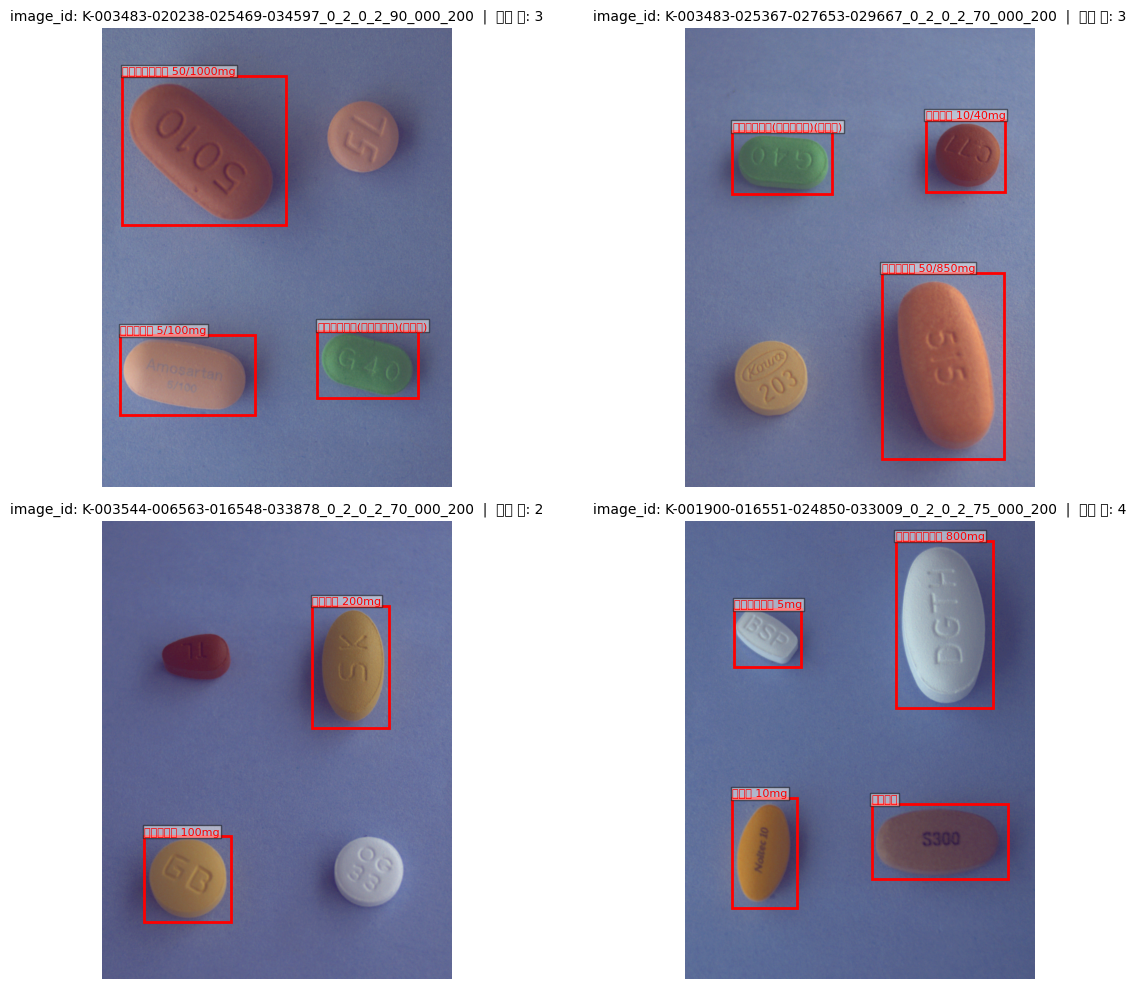

In [22]:
cat_id_to_name = {cat["id"]: cat["name"] for cat in train_data["categories"]}
sample_ids = random.sample(list(df["image_id"].unique()), 4)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, img_id in zip(axes, sample_ids):
    df_img = df[df["image_id"] == img_id]
    img_path = df_img["image_path"].iloc[0]
    
    image = Image.open(img_path).convert("RGB")
    ax.imshow(image)
    for _, row in df_img.iterrows():
        x1 = row["bbox_x"]
        y1 = row["bbox_y"]
        w  = row["bbox_w"]
        h  = row["bbox_h"]
        cat_id = int(row["category_id"])
        cat_name = cat_id_to_name.get(cat_id, str(cat_id))
        
        rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
        
        ax.text(
            x1, y1 - 5,
            cat_name,
            color="red", fontsize=8,
            bbox=dict(facecolor="white", alpha=0.5, pad=1))
    
    ax.set_title(f"image_id: {img_id}  |  객체 수: {len(df_img)}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show() 

=== 이미지당 알약 개수 통계 ===
count    1489.000000
mean        3.039624
std         0.837889
min         1.000000
25%         3.000000
50%         3.000000
75%         4.000000
max         4.000000
dtype: float64

0개 (annotation 없음): 0장
1개 : 64장
2개 : 302장
3개 : 634장
4개 : 489장
5개 이상 : 0장


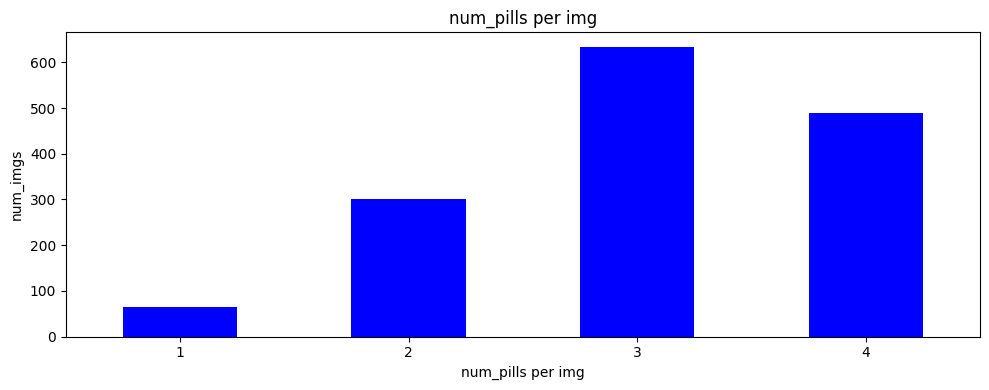

In [21]:
ann_counts = {}
for ann in train_data["annotations"]:
    img_id = ann["image_id"]
    ann_counts[img_id] = ann_counts.get(img_id, 0) + 1

# annotation 없는 이미지도 포함
for img in train_data["images"]:
    if img["id"] not in ann_counts:
        ann_counts[img["id"]] = 0

count_series = pd.Series(ann_counts.values())

# 통계
print("=== 이미지당 알약 개수 통계 ===")
print(count_series.describe())
print(f"\n0개 (annotation 없음): {(count_series == 0).sum()}장")
print(f"1개 : {(count_series == 1).sum()}장")
print(f"2개 : {(count_series == 2).sum()}장")
print(f"3개 : {(count_series == 3).sum()}장")
print(f"4개 : {(count_series == 4).sum()}장")
print(f"5개 이상 : {(count_series >= 5).sum()}장")

# 분포 시각화
plt.figure(figsize=(10, 4))
count_series.value_counts().sort_index().plot(kind="bar", color="blue")
plt.xlabel("num_pills per img")
plt.ylabel("num_imgs")
plt.title("num_pills per img")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [27]:
cat_counts = pd.Series([ann["category_id"] for ann in train_data["annotations"]]).value_counts().sort_index()
print("=== category별 annotation 수 ===")
print(cat_counts)
print(f"\n최대: {cat_counts.max()}개  |  최소: {cat_counts.min()}개")
print(f"평균: {cat_counts.mean():.1f}개")

=== category별 annotation 수 ===
1899     180
2482     172
3350     240
3482     514
3543      99
        ... 
35205    113
36636    108
38161     27
41767     23
44198     30
Name: count, Length: 73, dtype: int64

최대: 514개  |  최소: 7개
평균: 62.0개


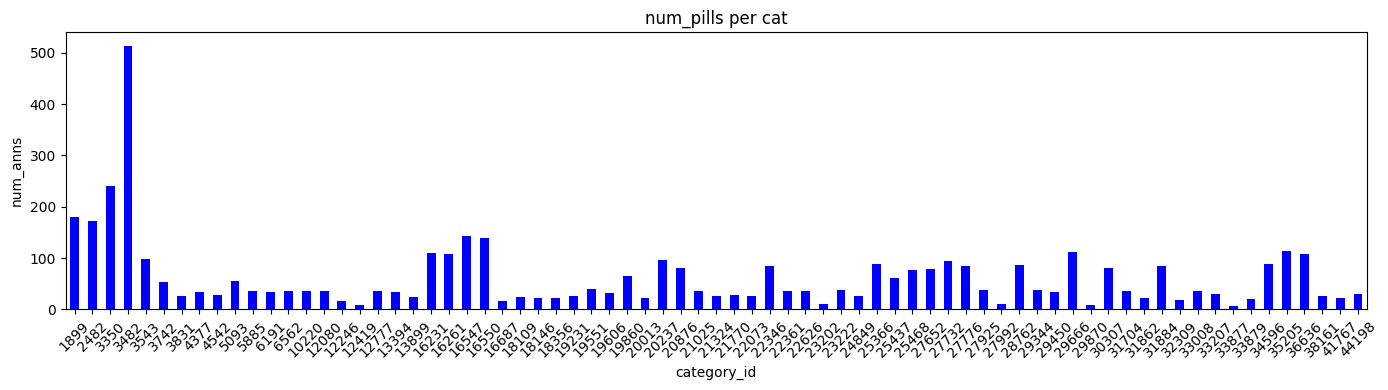

In [28]:
plt.figure(figsize=(14, 4))
cat_counts.plot(kind="bar", color="blue")
plt.xlabel("category_id")
plt.ylabel("num_anns")
plt.title("num_pills per cat")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
bins   = [0, 100, 200, 300, 400, float('inf')]
labels = ['1~100', '101~200', '201~300', '301~400', '400+']

bin_counts = pd.cut(cat_counts, bins=bins, labels=labels).value_counts().sort_index()

print("=== annotation 수 구간별 카테고리 개수 ===")
for label, count in bin_counts.items():
    print(f"{label:10s} : {count} cat")

=== annotation 수 구간별 카테고리 개수 ===
1~100      : 62 cat
101~200    : 9 cat
201~300    : 1 cat
301~400    : 0 cat
400+       : 1 cat


### 제안1> Img Augmentation 

In [ ]:
# from torchvision.tv_tensors import BoundingBoxes
# train_transforms = v2.Compose([v2.ToImage(),
#                              v2.RandomHorizontalFlip(p=0.3),
#                              v2.RandomPhotometricDistort(p=0.3),
#                              #v2.RandomRotation(degrees=15),
#                              v2.ToDtype(dtype=torch.float32, scale=True),
#                              v2.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)) 
#                              ])
# test_transforms = v2.Compose([ v2.ToImage(),
#                                 v2.ToDtype(dtype=torch.float32, scale=True),
#                                 v2.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
#                                 ])


In [ ]:
import cv2
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import WeightedRandomSampler

# ── transforms ──────────────────────────────────────────
train_transforms = A.Compose([A.Resize(640, 640),
                              A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, border_mode=0, p=0.8),
                              A.HorizontalFlip(p=0.5),
                              A.VerticalFlip(p=0.5),
                              A.RandomRotate90(p=0.5),
                              A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
                              A.CLAHE(clip_limit=4.0, p=0.4),
                              A.GaussNoise(p=0.3),
                              A.MotionBlur(blur_limit=3, p=0.2),
                              A.Normalize(mean=(0.485, 0.456, 0.406),std=(0.229, 0.224, 0.225)),
                              ToTensorV2()], 
                              bbox_params=A.BboxParams(format = 'coco',
                                                        label_fields = ['category_ids'],
                                                        min_area = 1.0,
                                                        min_visibility = 0.1,
                                                        clip = True )) # bbox 이탈문제로 clip해줘야함.

val_transforms = A.Compose([A.Resize(640, 640),
                            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
                            ToTensorV2()], 
                            bbox_params=A.BboxParams(
                                format = 'coco',
                                label_fields = ['category_ids'],
                                clip = True))

# ── Dataset ──────────────────────────────────────────────
class OralDrugDataset(torch.utils.data.Dataset):
    def __init__(self, df, orig2model, transforms=None):
        self.df         = df.reset_index(drop=True)
        self.orig2model = orig2model
        self.transforms = transforms
        # ✅ self.df 기준으로 그룹핑
        self.grouped    = {img_id: grp
                           for img_id, grp in self.df.groupby("image_id")}
        self.image_ids  = list(self.grouped.keys())

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        df_img   = self.grouped[image_id]
        img_path = df_img["image_path"].iloc[0]

        # ✅ numpy array로 로드 (albumentations 필수)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        bboxes, category_ids = [], []
        for _, row in df_img.iterrows():
            w, h = row["bbox_w"], row["bbox_h"]
            if w <= 1 or h <= 1:
                continue
            # ✅ COCO format [x, y, w, h]
            bboxes.append([row["bbox_x"], row["bbox_y"], w, h])
            category_ids.append(self.orig2model[int(row["category_id"])])

        if self.transforms is not None:
            transformed  = self.transforms(
                image        = image,
                bboxes       = bboxes,
                category_ids = category_ids
            )
            # ✅ 각각 분리해서 꺼내기
            image        = transformed["image"]
            bboxes       = transformed["bboxes"]
            category_ids = transformed["category_ids"]
        else:
            image = torch.as_tensor(
                image / 255.0, dtype=torch.float32).permute(2, 0, 1)

        # ✅ XYXY 변환 + bboxes/labels 동시 필터링
        boxes_xyxy, valid_labels = [], []
        for (x, y, w, h), label in zip(bboxes, category_ids):
            if (x + w) > x and (y + h) > y:
                boxes_xyxy.append([x, y, x+w, y+h])
                valid_labels.append(label)

        boxes_tensor = (torch.tensor(boxes_xyxy, dtype=torch.float32)
                        if boxes_xyxy
                        else torch.zeros((0, 4), dtype=torch.float32))

        target = {
            "boxes"   : boxes_tensor,
            "labels"  : torch.tensor(valid_labels, dtype=torch.int64),
            "image_id": torch.tensor([idx]),
        }

        return image, target
cat_counts  = df.groupby("category_id").size()
total       = cat_counts.sum()
cat_weight  = {cat_id: total / count for cat_id, count in cat_counts.items()}

sample_weights = []
for img_id in train_dataset_full.image_ids:
    df_img = df[df["image_id"] == img_id]
    weight = max(
        cat_weight.get(int(row["category_id"]), 1.0)
        for _, row in df_img.iterrows()
    )
    sample_weights.append(weight)

train_weights = [sample_weights[i] for i in train_indices]

sampler = WeightedRandomSampler(
    weights     = train_weights,
    num_samples = len(train_weights),
    replacement = True
)

# ── Dataset / DataLoader 구성 ────────────────────────────
train_dataset_full = OralDrugDataset(df, orig2model, transforms=train_transforms)
val_dataset_full   = OralDrugDataset(df, orig2model, transforms=val_transforms)

indices       = torch.randperm(len(train_dataset_full)).tolist()
split         = int(0.9 * len(indices))
train_indices = indices[:split]
val_indices   = indices[split:]

train_dataset = torch.utils.data.Subset(train_dataset_full, train_indices)
val_dataset   = torch.utils.data.Subset(val_dataset_full,   val_indices)

def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(train_dataset, batch_size=2,
                          shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=2,
                          shuffle=False, collate_fn=collate_fn)

print("train steps:", len(train_loader), "| val steps:", len(val_loader))

In [ ]:
from torch.cuda.amp import GradScaler, autocast

############################################################
# 5. 모델 정의
############################################################
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
model.to(device)

############################################################
# 6. 학습 루프
############################################################
num_epochs = 20

optimizer = optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-4,
    weight_decay=1e-4
)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)
scaler    = GradScaler()

for epoch in range(num_epochs):
    ##########################
    # 1) Train
    ##########################
    model.train()
    train_loss_sum = 0.0

    for images, targets in train_loader:
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()

        with autocast():
            loss_dict = model(images, targets)
            losses    = sum(loss for loss in loss_dict.values())

        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss_sum += losses.item()

    avg_train_loss = train_loss_sum / max(1, len(train_loader))

    ##########################
    # 2) Validation
    ##########################
    model.train()
    val_loss_sum = 0.0

    with torch.no_grad():
        for images, targets in val_loader:
            images  = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            with autocast():
                loss_dict = model(images, targets)
                losses    = sum(loss for loss in loss_dict.values())

            val_loss_sum += losses.item()

    avg_val_loss = val_loss_sum / max(1, len(val_loader))
    print(f"[Epoch {epoch+1}/{num_epochs}] " f"train_loss: {avg_train_loss:.4f} | val_loss: {avg_val_loss:.4f}")

    scheduler.step()

# 모델 저장
#torch.save(model.state_dict(), "fasterrcnn_oral_drug.pth")
#print("✅ 모델 저장 완료")

In [ ]:
class OralDrugDataset(Dataset):
    def __init__(self, df, orig2model, transforms=None):
        self.df         = df.reset_index(drop=True)
        self.orig2model = orig2model
        self.transforms = transforms      
        self.image_ids  = self.df["image_id"].unique().tolist()

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        df_img   = self.df[self.df["image_id"] == image_id]
        img_path = df_img["image_path"].iloc[0]
        image    = Image.open(img_path).convert("RGB")

        boxes  = []
        labels = []

        for _, row in df_img.iterrows():
            x, y, w, h = row["bbox_x"], row["bbox_y"], row["bbox_w"], row["bbox_h"]
            boxes.append([x, y, x+w, y+h])
            orig_cat = int(row["category_id"])
            labels.append(self.orig2model[orig_cat])

        boxes = BoundingBoxes(boxes, format="XYXY", canvas_size=(image.height, image.width))
        labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes"   : boxes,
            "labels"  : labels,
            "image_id": torch.tensor([idx]),
        }

        # transform 적용 (image + bbox 같이)
        if self.transforms is not None:
            image, target = self.transforms(image, target)

        return image, target

In [ ]:
import torch
from torch.utils.data import Subset, WeightedRandomSampler
import numpy as np

# 1. base dataset
dataset = OralDrugDataset(df, orig2model=orig2model, transforms=None)
# 2. index split
indices = torch.randperm(len(dataset)).tolist()

split = int(0.9 * len(indices))
train_indices = indices[:split]
val_indices   = indices[split:]

# 3. weight 계산  
total = cat_counts.sum()
cat_weight = {cat_id: total / count for cat_id, count in cat_counts.items()}

sample_weights = []

for img_id in dataset.image_ids: # 전체 dataset 
    df_img = df[df["image_id"] == img_id]

    weight = max(
        cat_weight.get(int(row["category_id"]), 1.0)
        for _, row in df_img.iterrows()
    )
    sample_weights.append(weight)

# 4. train subset용 weight 추출
train_weights = [sample_weights[i] for i in train_indices]

sampler = WeightedRandomSampler(
    weights=train_weights,
    num_samples=len(train_weights),
    replacement=True
)

# 5. dataset (transform 적용)
train_dataset = OralDrugDataset(df, orig2model=orig2model, transforms=train_transforms)
val_dataset   = OralDrugDataset(df, orig2model=orig2model, transforms=test_transforms)

train_dataset = Subset(train_dataset, train_indices)
val_dataset   = Subset(val_dataset,   val_indices)

# 6. dataloader
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler,   # no shuffle
    num_workers=4,
    collate_fn=collate_fn
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    collate_fn=collate_fn
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
# # 조건AUG

# class OralDrugDataset(Dataset):
#     def __init__(self, df, orig2model, transforms=None): # low_cats=None
#         self.df            = df.reset_index(drop=True)
#         self.orig2model    = orig2model
#         self.train_transforms    = train_transforms # 기본 변환
#         self.test_transforms = test_transforms # 증강 변환
#         # self.low_cats      = low_cats or set()
#         self.image_ids     = self.df["image_id"].unique().tolist()

#     def __len__(self):
#          return len(self.image_ids)

#     def __getitem__(self, idx):
#         image_id = self.image_ids[idx]
#         df_img   = self.df[self.df["image_id"] == image_id]
#         img_path = df_img["image_path"].iloc[0]
#         image    = Image.open(img_path).convert("RGB")

#         boxes  = []
#         labels = []
#         #cats   = []

#         for _, row in df_img.iterrows():
#             x, y, w, h = row["bbox_x"], row["bbox_y"], row["bbox_w"], row["bbox_h"]
#             boxes.append([x, y, x+w, y+h])
#             orig_cat = int(row["category_id"])
#             labels.append(self.orig2model[orig_cat])
#             cats.append(orig_cat)

#         boxes = BoundingBoxes(boxes,
#                               format="XYXY",
#                               canvas_size=(image.height, image.width))
#         labels = torch.tensor(labels, dtype=torch.int64)

#         target = {
#             "boxes"   : boxes,
#             "labels"  : labels,
#             "image_id": torch.tensor([idx]),
#         }

#         # low cats -> img augmentation
#         # is_low_cat = any(c in self.low_cats for c in cats)

#         # if is_low_cat and self.aug_transforms is not None:
#         #     image, target = self.aug_transforms(image, target)
#         # elif self.transforms is not None:
#         #     image, target = self.transforms(image, target)

#         if self.train_transforms is not None:
#           image, target = self.train_transforms(image, target)
      
#         return image, target

In [ ]:
# dataset = OralDrugDataset(df_balanced, orig2model=orig2model, transforms=train_transforms)

# # 간단히 train/val split (예: 90% train, 10% val)
# indices = torch.randperm(len(dataset)).tolist()
# split = int(0.9 * len(indices))
# train_indices = indices[:split]
# val_indices   = indices[split:]

# train_dataset = torch.utils.data.Subset(dataset, train_indices)
# val_dataset   = torch.utils.data.Subset(dataset, val_indices)

# def collate_fn(batch):
#     # detection 모델용 collate_fn: 리스트의 튜플을 튜플의 리스트로
#     return tuple(zip(*batch))

# train_loader = DataLoader(
#     train_dataset,
#     batch_size=2,              # GPU 메모리에 맞게 조정
#     shuffle=True,
#     collate_fn=collate_fn,
# )

# val_loader = DataLoader(
#     val_dataset,
#     batch_size=2,
#     shuffle=False,
#     collate_fn=collate_fn,
# )

# print("train steps:", len(train_loader), "val steps:", len(val_loader))


train steps: 669 val steps: 75


In [30]:
indices       = torch.randperm(len(dataset)).tolist()
split         = int(0.9 * len(indices))
train_indices = indices[:split]
val_indices   = indices[split:]

train_dataset = torch.utils.data.Subset(dataset, train_indices)
val_dataset   = torch.utils.data.Subset(dataset, val_indices)

### 제안2> weighted random sampler

In [ ]:
# from torch.utils.data import WeightedRandomSampler
# import numpy as np

In [ ]:
# total = cat_counts.sum()
# cat_weight = {cat_id: total / count for cat_id, count in cat_counts.items()}

# sample_weights = []
# for img_id in train_dataset.image_ids:
#     df_img = df[df["image_id"] == img_id]
#     weight = max(cat_weight.get(int(row["category_id"]), 1.0) # max->mean
#         for _, row in df_img.iterrows())
#     sample_weights.append(weight)

# train_weights = [sample_weights[i] for i in train_indices]

# sampler = WeightedRandomSampler(
#     weights     = train_weights,
#     num_samples = len(train_weights),
#     replacement = True)

# def collate_fn(batch):
#     return tuple(zip(*batch))

# train_loader = DataLoader(
#     train_dataset,
#     batch_size = 2,
#     sampler    = sampler,    # shuffle X
#     collate_fn = collate_fn)


# val_loader = DataLoader(
#     val_dataset,
#     batch_size = 2,
#     shuffle    = False,
#     collate_fn = collate_fn)

# print("train steps:", len(train_loader), "val steps  :", len(val_loader))

IndexError: list index out of range

### YOLO model


In [5]:
extract_path = normalize_path("/content/drive/MyDrive/data/초급_프로젝트/dataset/")

TRAIN_JSON_PATH = os.path.join(extract_path, "merged_annotations_train_final.json")
TEST_JSON_PATH = os.path.join(extract_path, "merged_annotations_test_final.json")
TRAIN_IMG_DIR = os.path.join(extract_path, "train_images")
TEST_IMG_DIR  = os.path.join(extract_path, "test_images")

In [6]:
with open(TRAIN_JSON_PATH, 'r') as f:
    train_data = json.load(f)

In [7]:
with open(TEST_JSON_PATH, 'r') as f:
    test_data = json.load(f)

In [9]:
print(test_data['images'][0])

{'file_name': 'K-001900-016551-024850-027926_0_2_0_2_75_000_200.png', 'width': 976, 'height': 1280, 'imgfile': 'K-001900-016551-024850-027926_0_2_0_2_75_000_200.png', 'drug_N': 'K-027926', 'drug_S': '정상알약', 'back_color': '연회색 배경', 'drug_dir': '앞면', 'light_color': '주백색', 'camera_la': 75, 'camera_lo': 0, 'size': 200, 'dl_idx': '27925', 'dl_mapping_code': 'K-027926', 'dl_name': '울트라셋이알서방정', 'dl_name_en': 'Ultracet ER Tab.', 'img_key': 'http://connectdi.com/design/img/drug/1NOwp2F6It9.jpg', 'dl_material': '아세트아미노펜|트라마돌염산염', 'dl_material_en': 'Acetaminophen| Tramadol Hydrochloride', 'dl_custom_shape': '서방형정제', 'dl_company': '(주)한국얀센', 'dl_company_en': 'Janssen Korea', 'di_company_mf': '', 'di_company_mf_en': '', 'item_seq': 201006967, 'di_item_permit_date': '20101122', 'di_class_no': '[01140]해열.진통.소염제', 'di_etc_otc_code': '전문의약품', 'di_edi_code': '646901630', 'chart': '노란색의 장방형 필름코팅 서방정제', 'drug_shape': '타원형', 'thick': 7, 'leng_long': 19, 'leng_short': 9, 'print_front': 'T/A ER', 'print_back

In [10]:
print(test_data['annotations'][0])

{'area': 128642, 'iscrowd': 0, 'bbox': [571, 628, 262, 491], 'category_id': 27925, 'ignore': 0, 'segmentation': [], 'id': 4, 'image_id': 3}


In [12]:
print(test_data['categories'][:3])
print(train_data['categories'][:3])  # train

[{'supercategory': 'pill', 'id': 27925, 'name': '울트라셋이알서방정'}, {'supercategory': 'pill', 'id': 24849, 'name': '놀텍정 10mg'}, {'supercategory': 'pill', 'id': 29344, 'name': '비모보정 500/20mg'}]
[{'supercategory': 'pill', 'id': 1899, 'name': '보령부스파정 5mg'}, {'supercategory': 'pill', 'id': 27925, 'name': '울트라셋이알서방정'}, {'supercategory': 'pill', 'id': 16550, 'name': '동아가바펜틴정 800mg'}]


In [13]:
# train의 category_id가 dl_idx 기반인지 확인
print(train_data['categories'][:3])
# {'id': 1899, 'name': ...}  ← 1899가 dl_idx인지?

# train annotation category_id 샘플
print(train_data['annotations'][0])

[{'supercategory': 'pill', 'id': 1899, 'name': '보령부스파정 5mg'}, {'supercategory': 'pill', 'id': 27925, 'name': '울트라셋이알서방정'}, {'supercategory': 'pill', 'id': 16550, 'name': '동아가바펜틴정 800mg'}]
{'area': 25654, 'iscrowd': 0, 'bbox': [158, 251, 202, 127], 'category_id': 1899, 'ignore': 0, 'segmentation': [], 'id': 1, 'image_id': 1}


In [30]:
def build_df_from_train_json(json_path, img_dir):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # 1) 이미지 정보 매핑 (id -> file_name) : TRAIN DATA!!
    id_to_fname = {img["id"]: img["file_name"] for img in data["images"]}

    records = []
    # 2) 어노테이션 순회
    for ann in data["annotations"]:
        img_id_coco = ann["image_id"]
        file_name = id_to_fname.get(img_id_coco)
        
        if file_name is None: continue
        
        img_path = os.path.join(img_dir, file_name)
        
        # 실제 이미지 파일이 있는지 확인 (선택 사항이지만 안전함)
        if not os.path.exists(img_path):
            continue

        x, y, w, h = ann["bbox"]
        
        records.append({
            "image_path": img_path,
            "image_id": os.path.splitext(file_name)[0], # 파일명을 ID로 사용
            "category_id": int(ann["category_id"]),
            "bbox_x": float(x),
            "bbox_y": float(y),
            "bbox_w": float(w),
            "bbox_h": float(h),
        })

    return pd.DataFrame(records)

df= build_df_from_train_json(TRAIN_JSON_PATH, TRAIN_IMG_DIR)
print(f" train 데이터: {len(df)}개 객체")
print(f" train 이미지: {df['image_id'].nunique()}장")



 train 데이터: 4526개 객체
 train 이미지: 1489장


In [15]:
import random
import pandas as pd

# 랜덤 시드 고정
random.seed(42)

# 1) 이미지 ID 리스트 가져오기
unique_image_ids = df["image_id"].unique().tolist()
random.shuffle(unique_image_ids)

# 2) 9:1 비율로 split
split_idx = int(0.9 * len(unique_image_ids))
train_ids = unique_image_ids[:split_idx]
val_ids   = unique_image_ids[split_idx:]

# 3) 이미지 ID 기준으로 데이터프레임 분할
train_df = df[df["image_id"].isin(train_ids)].reset_index(drop=True)
val_df   = df[df["image_id"].isin(val_ids)].reset_index(drop=True)

print(f"✅ Train 데이터: {len(train_df)}개 객체, {train_df['image_id'].nunique()}장 이미지")
print(f"✅ Val 데이터:   {len(val_df)}개 객체, {val_df['image_id'].nunique()}장 이미지")

✅ Train 데이터: 4063개 객체, 1340장 이미지
✅ Val 데이터:   463개 객체, 149장 이미지


In [31]:
import os
import json
import random
import pandas as pd
import yaml
from tqdm.auto import tqdm




# -----------------------------
# 2) Train/Val split
# -----------------------------
def split_train_val(df, val_ratio=0.1, seed=42):
    random.seed(seed)
    unique_image_ids = df["image_id"].unique().tolist()
    random.shuffle(unique_image_ids)
    
    split_idx = int(len(unique_image_ids)*(1-val_ratio))
    train_ids = unique_image_ids[:split_idx]
    val_ids   = unique_image_ids[split_idx:]

    train_df = df[df["image_id"].isin(train_ids)].reset_index(drop=True)
    val_df   = df[df["image_id"].isin(val_ids)].reset_index(drop=True)

    print(f"✅ Train 데이터: {len(train_df)}개 객체, {train_df['image_id'].nunique()}장 이미지")
    print(f"✅ Val 데이터:   {len(val_df)}개 객체, {val_df['image_id'].nunique()}장 이미지")
    
    return train_df, val_df


In [32]:

# -----------------------------
# 3) 클래스 매핑
# -----------------------------
def build_class_mappings(df):
    unique_cats = sorted(df['category_id'].unique())
    orig2model_yolo = {cid: i for i, cid in enumerate(unique_cats)}
    model2orig_yolo = {v: k for k, v in orig2model_yolo.items()}
    num_classes = len(orig2model_yolo)
    print(f"✅ 클래스 수: {num_classes}")
    return orig2model_yolo, model2orig_yolo, num_classes, unique_cats

In [33]:

# -----------------------------
# 4) YOLO 라벨 생성 (벡터화)
# -----------------------------
def save_yolo_labels_fast(df, output_dir, orig2model_yolo, img_size=1280):
    os.makedirs(output_dir, exist_ok=True)
    df = df.copy()
    df['cls'] = df['category_id'].map(orig2model_yolo)
    df['x_center'] = (df['bbox_x'] + df['bbox_w']/2) / img_size
    df['y_center'] = (df['bbox_y'] + df['bbox_h']/2) / img_size
    df['w_n'] = df['bbox_w'] / img_size
    df['h_n'] = df['bbox_h'] / img_size

    for img_id, group in tqdm(df.groupby('image_id'), desc=f"Saving labels to {output_dir}"):
        lines = "\n".join(
            f"{int(r.cls)} {r.x_center:.6f} {r.y_center:.6f} {r.w_n:.6f} {r.h_n:.6f}"
            for r in group.itertuples()
        )
        with open(os.path.join(output_dir, f"{img_id}.txt"), "w") as f:
            f.write(lines + "\n")

In [38]:
import os

os.makedirs("/content/yolo_dataset/images/train", exist_ok=True)
os.makedirs("/content/yolo_dataset/images/val", exist_ok=True)
os.makedirs("/content/yolo_dataset/labels/train", exist_ok=True)
os.makedirs("/content/yolo_dataset/labels/val", exist_ok=True)

In [41]:
import shutil
from tqdm import tqdm

# train 이미지 복사
for img_file in tqdm(train_df['image_path'].unique(), desc="Copying train images"):
    if os.path.exists(img_file):
        shutil.copy(img_file, "/content/yolo_dataset/images/train")
    else:
        print("Missing train image:", img_file)

# val 이미지 복사
for img_file in tqdm(val_df['image_path'].unique(), desc="Copying val images"):
    if os.path.exists(img_file):
        shutil.copy(img_file, "/content/yolo_dataset/images/val")
    else:
        print("Missing val image:", img_file)

Copying val images: 100%|██████████| 149/149 [00:02<00:00, 53.28it/s]


In [42]:

# -----------------------------
# 5) YOLO YAML 생성
# -----------------------------
def create_yolo_yaml(yolo_root_dir, train_dir, val_dir, num_classes, class_names):
    data_yaml = {
        "train": train_dir,
        "val": val_dir,
        "nc": num_classes,
        "names": class_names
    }
    yaml_path = os.path.join(yolo_root_dir, "dataset.yaml")
    with open(yaml_path, "w") as f:
        yaml.dump(data_yaml, f, sort_keys=False)
    print(f"✅ YOLO YAML 생성 완료: {yaml_path}")
    return yaml_path

# -----------------------------
# 6) 통합 실행 예시
# -----------------------------
TRAIN_JSON_PATH = "/content/train.json"
TRAIN_IMG_DIR = "/content/train_images"
YOLO_ROOT_DIR = "/content/yolo_dataset"

# 라벨 저장 폴더
TRAIN_LABEL_DIR = os.path.join(YOLO_ROOT_DIR, "labels/train")
VAL_LABEL_DIR   = os.path.join(YOLO_ROOT_DIR, "labels/val")

# 이미지 폴더 (YOLO 학습용)
TRAIN_IMG_YOLO_DIR = os.path.join(YOLO_ROOT_DIR, "images/train")
VAL_IMG_YOLO_DIR   = os.path.join(YOLO_ROOT_DIR, "images/val")

 

# 2) Train/Val split
train_df, val_df = split_train_val(df)

# 3) 클래스 매핑
orig2model_yolo, model2orig_yolo, num_classes, unique_cats = build_class_mappings(df)

# 4) 라벨 생성
save_yolo_labels_fast(train_df, TRAIN_LABEL_DIR, orig2model_yolo)
save_yolo_labels_fast(val_df, VAL_LABEL_DIR, orig2model_yolo)

# 5) YAML 생성
CLASS_NAMES = [f"class{i}" for i in range(num_classes)]  # 필요시 실제 클래스명 리스트로 변경
create_yolo_yaml(YOLO_ROOT_DIR, TRAIN_IMG_YOLO_DIR, VAL_IMG_YOLO_DIR, num_classes, CLASS_NAMES)

✅ Train 데이터: 4063개 객체, 1340장 이미지
✅ Val 데이터:   463개 객체, 149장 이미지
✅ 클래스 수: 73


Saving labels to /content/yolo_dataset/labels/train: 100%|██████████| 1340/1340 [00:01<00:00, 1173.93it/s]
Saving labels to /content/yolo_dataset/labels/val: 100%|██████████| 149/149 [00:00<00:00, 1115.44it/s]

✅ YOLO YAML 생성 완료: /content/yolo_dataset/dataset.yaml


'/content/yolo_dataset/dataset.yaml'

==============================YAML for split===================================

In [9]:
# FOR TEST DATA!!!
def build_df_from_test_json(json_path, img_dir):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # file_name 대신 id.png로 매핑 : TEST DATA!!!
    id_to_fname = {img["id"]: str(img["id"]) + ".png" for img in data["images"]}

    records = []
    for ann in data["annotations"]:
        img_id_coco = ann["image_id"]
        file_name = id_to_fname.get(img_id_coco)

        if file_name is None: continue

        img_path = os.path.join(img_dir, file_name)
        if not os.path.exists(img_path):
            continue

        x, y, w, h = ann["bbox"]
        records.append({
            "image_path": img_path,
            "image_id": os.path.splitext(file_name)[0],  # "576"
            "category_id": int(ann["category_id"]),
            "bbox_x": float(x),
            "bbox_y": float(y),
            "bbox_w": float(w),
            "bbox_h": float(h),
        })

    return pd.DataFrame(records)

# 실행
df_test = build_df_from_test_json(TEST_JSON_PATH, TEST_IMG_DIR)
print(f" test 데이터: {len(df_test)}개 객체")
print(f" test 이미지: {df_test['image_id'].nunique()}장")


 test 데이터: 1129개 객체
 test 이미지: 843장


In [16]:
# FOR TRAIN
unique_cats = sorted(df["category_id"].unique())
print(len(unique_cats))

73


In [11]:
# FOR TEST
unique_cats_test = sorted(df_test["category_id"].unique())
print(len(unique_cats_test))

73


In [12]:
# FOR TRAIN
orig2model_yolo = {cid: i for i, cid in enumerate(unique_cats)}  # without background
model2orig_yolo = {v: k for k, v in orig2model_yolo.items()}
num_classes = len(orig2model_yolo)  # it should be 73
print(num_classes)

73


In [13]:
# FOR TEST
orig2model_yolo_test = {cid: i for i, cid in enumerate(unique_cats_test)}  # without background
model2orig_yolo_test = {v: k for k, v in orig2model_yolo_test.items()}
num_classes_test = len(orig2model_yolo_test)  # it should be 73
print(num_classes_test)

73


In [32]:
orig2model_yolo_test, model2orig_yolo_test

({np.int64(1899): 0,
  np.int64(2482): 1,
  np.int64(3350): 2,
  np.int64(3482): 3,
  np.int64(3543): 4,
  np.int64(3742): 5,
  np.int64(3831): 6,
  np.int64(4377): 7,
  np.int64(4542): 8,
  np.int64(5093): 9,
  np.int64(5885): 10,
  np.int64(6191): 11,
  np.int64(6562): 12,
  np.int64(10220): 13,
  np.int64(12080): 14,
  np.int64(12246): 15,
  np.int64(12419): 16,
  np.int64(12777): 17,
  np.int64(13394): 18,
  np.int64(13899): 19,
  np.int64(16231): 20,
  np.int64(16261): 21,
  np.int64(16547): 22,
  np.int64(16550): 23,
  np.int64(16687): 24,
  np.int64(18109): 25,
  np.int64(18146): 26,
  np.int64(18356): 27,
  np.int64(19231): 28,
  np.int64(19551): 29,
  np.int64(19606): 30,
  np.int64(19860): 31,
  np.int64(20013): 32,
  np.int64(20237): 33,
  np.int64(20876): 34,
  np.int64(21025): 35,
  np.int64(21324): 36,
  np.int64(21770): 37,
  np.int64(22073): 38,
  np.int64(22346): 39,
  np.int64(22361): 40,
  np.int64(22626): 41,
  np.int64(23202): 42,
  np.int64(23222): 43,
  np.int64(

In [ ]:
orig2model_yolo, model2orig_yolo # TRAIN

({np.int64(1899): 0,
  np.int64(2482): 1,
  np.int64(3350): 2,
  np.int64(3482): 3,
  np.int64(3543): 4,
  np.int64(3742): 5,
  np.int64(3831): 6,
  np.int64(4377): 7,
  np.int64(4542): 8,
  np.int64(5093): 9,
  np.int64(5885): 10,
  np.int64(6191): 11,
  np.int64(6562): 12,
  np.int64(10220): 13,
  np.int64(12080): 14,
  np.int64(12246): 15,
  np.int64(12419): 16,
  np.int64(12777): 17,
  np.int64(13394): 18,
  np.int64(13899): 19,
  np.int64(16231): 20,
  np.int64(16261): 21,
  np.int64(16547): 22,
  np.int64(16550): 23,
  np.int64(16687): 24,
  np.int64(18109): 25,
  np.int64(18146): 26,
  np.int64(18356): 27,
  np.int64(19231): 28,
  np.int64(19551): 29,
  np.int64(19606): 30,
  np.int64(19860): 31,
  np.int64(20013): 32,
  np.int64(20237): 33,
  np.int64(20876): 34,
  np.int64(21025): 35,
  np.int64(21324): 36,
  np.int64(21770): 37,
  np.int64(22073): 38,
  np.int64(22346): 39,
  np.int64(22361): 40,
  np.int64(22626): 41,
  np.int64(23202): 42,
  np.int64(23222): 43,
  np.int64(

In [ ]:
# import os

# # 1. YOLO 라벨을 저장할 경로 설정 (이미지 폴더와 같은 레벨의 labels 폴더)
# # extract_path를 기준으로 'labels' 폴더를 지정!
# YOLO_LABEL_DIR = os.path.join(extract_path, "labels") 

# def save_yolo_labels_v2(df, output_path):
#     os.makedirs(output_path, exist_ok=True)
    
#     # 해상도 검사했을 때 1280이었으므로 변수로 지정해서 계산
#     IMG_W, IMG_H = 1280, 1280
    
#     for img_id, group in df.groupby('image_id'):
#         # 파일명 기반으로 .txt 파일 생성
#         label_file = os.path.join(output_path, f"{img_id}.txt")
        
#         with open(label_file, 'w', encoding='utf-8') as f:
#             for _, row in group.iterrows():
#                 cls = orig2model_yolo[int(row['category_id'])] # CAT수정
                
#                 # 좌표 변환 (Center X, Center Y, Width, Height) / Image Size
#                 x_center = (row['bbox_x'] + row['bbox_w'] / 2) / IMG_W
#                 y_center = (row['bbox_y'] + row['bbox_h'] / 2) / IMG_H
#                 w = row['bbox_w'] / IMG_W
#                 h = row['bbox_h'] / IMG_H
                
#                 # YOLO 포맷으로 쓰기
#                 f.write(f"{cls} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}\n")

# # ✅ 실행
# save_yolo_labels_v2(df, YOLO_LABEL_DIR)

# print(f"✅ YOLO 라벨 생성 완료: {YOLO_LABEL_DIR}")
# print(f"📁 생성된 라벨 수: {len(os.listdir(YOLO_LABEL_DIR))} 개")

KeyboardInterrupt: 

In [14]:
# 이건 동일하게 사용: TRAIN, TEST. 
def save_yolo_labels_fast(df, output_path):
    os.makedirs(output_path, exist_ok=True)
    IMG_W, IMG_H = 1280, 1280

    # iterrows 대신 vectorized 연산으로 한번에 계산
    df = df.copy()
    df['cls']      = df['category_id'].map(orig2model_yolo)
    df['x_center'] = (df['bbox_x'] + df['bbox_w'] / 2) / IMG_W
    df['y_center'] = (df['bbox_y'] + df['bbox_h'] / 2) / IMG_H
    df['w_n']      = df['bbox_w'] / IMG_W
    df['h_n']      = df['bbox_h'] / IMG_H

    # 이미지별로 한번에 문자열 생성 후 write
    for img_id, group in df.groupby('image_id'):
        lines = "\n".join(
            f"{int(r.cls)} {r.x_center:.6f} {r.y_center:.6f} {r.w_n:.6f} {r.h_n:.6f}"
            for r in group.itertuples()  # iterrows보다 3~5배 빠름
        )
        with open(os.path.join(output_path, f"{img_id}.txt"), 'w') as f:
            f.write(lines + "\n")

In [15]:
LOCAL_LABEL_DIR = "/content/labels"
save_yolo_labels_fast(df, LOCAL_LABEL_DIR)
print(f"train label: {len(os.listdir(LOCAL_LABEL_DIR))}") # 1489!!

train label: 1489


In [16]:
TEST_LABEL_LOCAL_DIR = "/content/test_labels"
save_yolo_labels_fast(df_test, TEST_LABEL_LOCAL_DIR)
print(f"test label: {len(os.listdir(TEST_LABEL_LOCAL_DIR))}") # 843

test label: 843


In [22]:
files = os.listdir(LOCAL_LABEL_DIR)
files[:5]

['K-003544-004543-016551-027993_0_2_0_2_70_000_200.txt',
 'K-003483-020238-027777-034597_0_2_0_2_70_000_200.txt',
 'K-003483-016232-027653-034597_0_2_0_2_70_000_200.txt',
 'K-003351-032310-036637_0_2_0_2_70_000_200.txt',
 'K-003483-027653-029667-031885_0_2_0_2_70_000_200.txt']

In [ ]:
with open(os.path.join(LOCAL_LABEL_DIR, files[0]), 'r') as f:
    print(f.read())

23 0.600391 0.364453 0.238281 0.352344
4 0.568359 0.761328 0.169531 0.166406
8 0.197266 0.759766 0.166406 0.164844
52 0.244531 0.260937 0.253125 0.125000



In [17]:
TRAIN_LABEL_DRIVE = "/content/drive/MyDrive/data/초급_프로젝트/dataset/labels"
print(f"train label: {len(os.listdir(TRAIN_LABEL_DRIVE))}개")

train label: 1489개


In [19]:
TEST_LABEL_DRIVE = "/content/drive/MyDrive/data/초급_프로젝트/dataset/test_labels"
print(f"train label: {len(os.listdir(TEST_LABEL_DRIVE))}개")

train label: 843개


In [ ]:
# COPY 했으면 안해도됨.
# import shutil

# TEST_LABEL_DRIVE = "/content/drive/MyDrive/data/초급_프로젝트/dataset/test_labels"

# shutil.copytree("/content/test_labels", TEST_LABEL_DRIVE, dirs_exist_ok=True)
# print(f"Drive 저장 완료: {len(os.listdir(TEST_LABEL_DRIVE))}개")

KeyboardInterrupt: 

In [ ]:
# # 3. 이미지 복사하는데 파일 하나씩 copy
# for img_id in df_test['image_id'].unique():
#     shutil.copy(os.path.join(TEST_IMG_DIR, img_id + ".jpg"), TEST_IMG_LOCAL)

# print(f"✅ test 이미지: {len(os.listdir(TEST_IMG_LOCAL))}장")
# print(f"✅ test 라벨:   {len(os.listdir(TEST_LABEL_LOCAL))}개")


In [9]:
TEST_LABEL_DRIVE = "/content/drive/MyDrive/data/초급_프로젝트/dataset/test_labels"
TRAIN_LABEL_DRIVE = "/content/drive/MyDrive/data/초급_프로젝트/dataset/labels"

In [20]:
os.makedirs("/content/yolo_data/train/images", exist_ok=True)
os.makedirs("/content/yolo_data/train/labels", exist_ok=True)
os.makedirs("/content/yolo_data/test/images", exist_ok=True)
os.makedirs("/content/yolo_data/test/labels", exist_ok=True)

In [21]:
import shutil, os

# Drive → 로컬 복사
shutil.copytree("/content/drive/MyDrive/data/초급_프로젝트/dataset/train_images",
                "/content/yolo_data/train/images", dirs_exist_ok=True)

shutil.copytree("/content/drive/MyDrive/data/초급_프로젝트/dataset/labels",
                "/content/yolo_data/train/labels", dirs_exist_ok=True)

shutil.copytree("/content/drive/MyDrive/data/초급_프로젝트/dataset/test_images",
                "/content/yolo_data/test/images",  dirs_exist_ok=True)

shutil.copytree("/content/drive/MyDrive/data/초급_프로젝트/dataset/test_labels",
                "/content/yolo_data/test/labels",  dirs_exist_ok=True)

print(f" train 이미지: {len(os.listdir('/content/yolo_data/train/images'))}장")
print(f" train 라벨:   {len(os.listdir('/content/yolo_data/train/labels'))}개")
print(f" test 이미지:  {len(os.listdir('/content/yolo_data/test/images'))}장")
print(f" test 라벨:    {len(os.listdir('/content/yolo_data/test/labels'))}개")

 train 이미지: 1489장
 train 라벨:   1489개
 test 이미지:  843장
 test 라벨:    843개


In [ ]:
import yaml

with open(TRAIN_JSON_PATH, "r", encoding="utf-8") as f:
    coco_data = json.load(f)

id_to_name = {cat["id"]: cat["name"] for cat in coco_data["categories"]}
names = [id_to_name[orig_id] for orig_id, _ in sorted(orig2model_yolo.items(), key=lambda x: x[1])]

yolo_yaml = {
    "path": "/content/yolo_data",  
    "train": "train/images",       
    "val":   "test/images",       
    "nc": num_classes,
    "names": names
}

# yolo_yaml = {
#     "path": "/content/drive/MyDrive/data/초급_프로젝트/dataset",
#     "train": "train_images",   # ← 수정
#     "val":   "test_images",   # ← 수정 (일단 동일)
#     "nc": num_classes,
#     "names": names
#}

yaml_path = "/content/dataset.yaml"
with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.dump(yolo_yaml, f, allow_unicode=True, sort_keys=False)

print(f"dataset.yaml 생성 완료")

# 내용 확인
with open(yaml_path, "r") as f:
    print(f.read())

dataset.yaml 생성 완료
path: /content/yolo_data
train: train/images
val: test/images
nc: 73
names:
- 보령부스파정 5mg
- 뮤테란캡슐 100mg
- 일양하이트린정 2mg
- 기넥신에프정(은행엽엑스)(수출용)
- 무코스타정(레바미피드)(비매품)
- 알드린정
- 뉴로메드정(옥시라세탐)
- 타이레놀정500mg
- 에어탈정(아세클로페낙)
- 삼남건조수산화알루미늄겔정
- 타이레놀이알서방정(아세트아미노펜)(수출용)
- 삐콤씨에프정 618.6mg/병
- 조인스정 200mg
- 쎄로켈정 100mg
- 리렉스펜정 300mg/PTP
- 아빌리파이정 10mg
- 자이프렉사정 2.5mg
- 다보타민큐정 10mg/병
- 써스펜8시간이알서방정 650mg
- 에빅사정(메만틴염산염)(비매품)
- 리피토정 20mg
- 크레스토정 20mg
- 가바토파정 100mg
- 동아가바펜틴정 800mg
- 오마코연질캡슐(오메가-3-산에틸에스테르90)
- 란스톤엘에프디티정 30mg
- 리리카캡슐 150mg
- 종근당글리아티린연질캡슐(콜린알포세레이트) 
- 콜리네이트연질캡슐 400mg
- 트루비타정 60mg/병
- 스토가정 10mg
- 노바스크정 5mg
- 마도파정
- 플라빅스정 75mg
- 엑스포지정 5/160mg
- 펠루비정(펠루비프로펜)
- 아토르바정 10mg
- 라비에트정 20mg
- 리피로우정 20mg
- 자누비아정 50mg
- 맥시부펜이알정 300mg
- 메가파워정 90mg/병
- 쿠에타핀정 25mg
- 비타비백정 100mg/병
- 놀텍정 10mg
- 자누메트정 50/850mg
- 큐시드정 31.5mg/PTP
- 아모잘탄정 5/100mg
- 세비카정 10/40mg
- 트윈스타정 40/5mg
- 카나브정 60mg
- 울트라셋이알서방정
- 졸로푸트정 100mg
- 트라젠타정(리나글립틴)
- 비모보정 500/20mg
- 레일라정
- 리바로정 4mg
- 렉사프로정 15mg
- 트라젠타듀오정 2.5/850mg
- 낙소졸정 500/2

In [52]:
#================class group==========================================================================
import re
from collections import defaultdict

# 1. 기존 names 리스트 (COCO JSON에서)
with open(TRAIN_JSON_PATH, "r", encoding="utf-8") as f:
    coco_data = json.load(f)

id_to_name = {cat["id"]: cat["name"] for cat in coco_data["categories"]}

# 2. 이름 정규화 함수
def normalize_name(name):
    name = re.sub(r"\(.*?\)", "", name)           # 괄호 제거
    name = re.sub(r"\d+(\.\d+)?\s*(mg|g|mcg|ml|iu)", "", name, flags=re.IGNORECASE)  # 용량 제거
    name = re.sub(r"/.*", "", name)               # / 이후 제거
    name = re.sub(r"\s+", " ", name).strip()      # 공백 정리
    return name

# 3. 통합 그룹 생성
grouped = defaultdict(list)
for orig_id, name in id_to_name.items():
    base = normalize_name(name)
    grouped[base].append(orig_id)

print(f"기존 클래스 수: {len(id_to_name)}")
print(f"통합 클래스 수: {len(grouped)}")

# 통합 결과 확인
for base, ids in grouped.items():
    if len(ids) > 1:
        print(f"  {base} ← {[id_to_name[i] for i in ids]}")

기존 클래스 수: 73
통합 클래스 수: 73


### Offline Data Augmentation 

In [25]:
# train 데이터 기준 instance 수
original_counts = df.groupby('category_id').size()
id_to_name = {cid: f"class_{cid}" for cid in df['category_id'].unique()}

print("=" * 50)
shortage = {}
TARGET = 60

for cat_id, total in sorted(original_counts.items()):
    status = "✅" if total >= TARGET else "❌"
    
    if total < TARGET:
        shortage[cat_id] = TARGET - total
    
    print(f"{status} {id_to_name[cat_id]}: {total}개")

print("=" * 50)

if len(shortage) == 0:
    print("✅ 모든 클래스 60개 이상!")
else:
    print(f"❌ {len(shortage)}개 클래스 부족 → 증강 필요")

✅ class_1899: 180개
✅ class_2482: 172개
✅ class_3350: 240개
✅ class_3482: 514개
✅ class_3543: 99개
❌ class_3742: 54개
❌ class_3831: 27개
❌ class_4377: 33개
❌ class_4542: 29개
❌ class_5093: 56개
❌ class_5885: 35개
❌ class_6191: 34개
❌ class_6562: 35개
❌ class_10220: 35개
❌ class_12080: 35개
❌ class_12246: 16개
❌ class_12419: 9개
❌ class_12777: 36개
❌ class_13394: 34개
❌ class_13899: 24개
✅ class_16231: 109개
✅ class_16261: 108개
✅ class_16547: 143개
✅ class_16550: 139개
❌ class_16687: 16개
❌ class_18109: 24개
❌ class_18146: 23개
❌ class_18356: 22개
❌ class_19231: 26개
❌ class_19551: 39개
❌ class_19606: 32개
✅ class_19860: 66개
❌ class_20013: 23개
✅ class_20237: 97개
✅ class_20876: 80개
❌ class_21025: 35개
❌ class_21324: 26개
❌ class_21770: 29개
❌ class_22073: 26개
✅ class_22346: 85개
❌ class_22361: 36개
❌ class_22626: 36개
❌ class_23202: 10개
❌ class_23222: 38개
❌ class_24849: 27개
✅ class_25366: 88개
✅ class_25437: 61개
✅ class_25468: 76개
✅ class_27652: 79개
✅ class_27732: 94개
✅ class_27776: 84개
❌ class_27925: 38개
❌ class_27992: 11개

In [27]:
shortage

{3742: 6,
 3831: 33,
 4377: 27,
 4542: 31,
 5093: 4,
 5885: 25,
 6191: 26,
 6562: 25,
 10220: 25,
 12080: 25,
 12246: 44,
 12419: 51,
 12777: 24,
 13394: 26,
 13899: 36,
 16687: 44,
 18109: 36,
 18146: 37,
 18356: 38,
 19231: 34,
 19551: 21,
 19606: 28,
 20013: 37,
 21025: 25,
 21324: 34,
 21770: 31,
 22073: 34,
 22361: 24,
 22626: 24,
 23202: 50,
 23222: 22,
 24849: 33,
 27925: 22,
 27992: 49,
 29344: 22,
 29450: 26,
 29870: 51,
 31704: 25,
 31862: 37,
 32309: 42,
 33008: 25,
 33207: 30,
 33877: 53,
 33879: 39,
 38161: 33,
 41767: 37,
 44198: 30}

In [29]:
import albumentations as A
import cv2
import numpy as np
import os
import shutil

# 증강 파이프라인
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.HueSaturationValue(p=0.3),
    A.GaussNoise(p=0.2),
    A.Blur(blur_limit=3, p=0.2),
], bbox_params=A.BboxParams(
    format='yolo',
    label_fields=['class_labels']
))

# 저장 경로
AUG_ONLY_IMG = "/content/aug_only/images"
AUG_ONLY_LBL = "/content/aug_only/labels"

# 처음 증강이므로 기존 폴더 삭제
if os.path.exists(AUG_ONLY_IMG):
    shutil.rmtree(AUG_ONLY_IMG)
if os.path.exists(AUG_ONLY_LBL):
    shutil.rmtree(AUG_ONLY_LBL)

os.makedirs(AUG_ONLY_IMG, exist_ok=True)
os.makedirs(AUG_ONLY_LBL, exist_ok=True)

for cat_id, need in shortage.items():

    cat_df = df[df['category_id'] == cat_id]

    if len(cat_df) == 0:
        print(f"⚠️ 클래스 {cat_id} 없음")
        continue

    aug_count = 0
    print(f"클래스 {cat_id}: {need}개 생성 중")

    while aug_count < need:
        row = cat_df.sample(1).iloc[0]
        img_path = row['image_path']

        try:
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ih, iw = img.shape[:2]
        except:
            continue

        img_group = df[df['image_id'] == row['image_id']]
        bboxes, class_labels = [], []

        for _, r in img_group.iterrows():
            cx = np.clip((r['bbox_x'] + r['bbox_w']/2) / iw, 0.01, 0.99)
            cy = np.clip((r['bbox_y'] + r['bbox_h']/2) / ih, 0.01, 0.99)
            w  = np.clip(r['bbox_w'] / iw, 0.01, 0.99)
            h  = np.clip(r['bbox_h'] / ih, 0.01, 0.99)

            bboxes.append([cx, cy, w, h])
            class_labels.append(orig2model_yolo[r['category_id']])

        try:
            result = augment(image=img, bboxes=bboxes, class_labels=class_labels)
        except:
            continue

        if len(result['bboxes']) == 0:
            continue

        aug_name = f"aug_{cat_id}_{aug_count}"

        aug_img = cv2.cvtColor(result['image'], cv2.COLOR_RGB2BGR)
        cv2.imwrite(os.path.join(AUG_ONLY_IMG, f"{aug_name}.png"), aug_img)

        with open(os.path.join(AUG_ONLY_LBL, f"{aug_name}.txt"), 'w') as f:
            for bbox, cls in zip(result['bboxes'], result['class_labels']):
                f.write(f"{cls} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n")

        aug_count += 1

print(f"len cls: {len(os.listdir(AUG_ONLY_IMG))}개 생성")

클래스 3742: 6개 생성 중
클래스 3831: 33개 생성 중
클래스 4377: 27개 생성 중
클래스 4542: 31개 생성 중
클래스 5093: 4개 생성 중
클래스 5885: 25개 생성 중
클래스 6191: 26개 생성 중
클래스 6562: 25개 생성 중
클래스 10220: 25개 생성 중
클래스 12080: 25개 생성 중
클래스 12246: 44개 생성 중
클래스 12419: 51개 생성 중
클래스 12777: 24개 생성 중
클래스 13394: 26개 생성 중
클래스 13899: 36개 생성 중
클래스 16687: 44개 생성 중
클래스 18109: 36개 생성 중
클래스 18146: 37개 생성 중
클래스 18356: 38개 생성 중
클래스 19231: 34개 생성 중
클래스 19551: 21개 생성 중
클래스 19606: 28개 생성 중
클래스 20013: 37개 생성 중
클래스 21025: 25개 생성 중
클래스 21324: 34개 생성 중
클래스 21770: 31개 생성 중
클래스 22073: 34개 생성 중
클래스 22361: 24개 생성 중
클래스 22626: 24개 생성 중
클래스 23202: 50개 생성 중
클래스 23222: 22개 생성 중
클래스 24849: 33개 생성 중
클래스 27925: 22개 생성 중
클래스 27992: 49개 생성 중
클래스 29344: 22개 생성 중
클래스 29450: 26개 생성 중
클래스 29870: 51개 생성 중
클래스 31704: 25개 생성 중
클래스 31862: 37개 생성 중
클래스 32309: 42개 생성 중
클래스 33008: 25개 생성 중
클래스 33207: 30개 생성 중
클래스 33877: 53개 생성 중
클래스 33879: 39개 생성 중
클래스 38161: 33개 생성 중
클래스 41767: 37개 생성 중
클래스 44198: 30개 생성 중
len cls: 1481개 생성


In [33]:
print("생성된 증강 이미지:", len(os.listdir(AUG_ONLY_IMG)))
print("생성된 증강 라벨:", len(os.listdir(AUG_ONLY_LBL)))
print("요청한 증강 수:", sum(shortage.values()))

생성된 증강 이미지: 1481
생성된 증강 라벨: 1481
요청한 증강 수: 1481


In [34]:
# 위의 코드에서 cat num가 9.0 float로 생성된 문제. ->수정 코드
for txt in os.listdir(AUG_ONLY_LBL):
    path = os.path.join(AUG_ONLY_LBL, txt)
    with open(path, 'r') as f:
        lines = f.readlines()
    
    with open(path, 'w') as f:
        for line in lines:
            if line.strip() == "": continue
            parts = line.split()
            cls   = int(float(parts[0]))  # "9.0" → 9
            f.write(f"{cls} {parts[1]} {parts[2]} {parts[3]} {parts[4]}\n")

print("✅ 기존 파일 수정 완료")

✅ 기존 파일 수정 완료


In [35]:
# 1. 원본 train instance 수
original_counts = df.groupby('category_id').size()

# 2. 증강 라벨 instance 수
aug_counts = {}

for txt in os.listdir(AUG_ONLY_LBL):
    with open(os.path.join(AUG_ONLY_LBL, txt)) as f:
        for line in f:
            cls = int(line.split()[0])
            aug_counts[cls] = aug_counts.get(cls, 0) + 1

# 3. 합산
final_counts = {}

for cat_id, count in original_counts.items():
    model_cls = orig2model_yolo[cat_id]
    aug = aug_counts.get(model_cls, 0)
    final_counts[cat_id] = count + aug

# 4. 다시 60 미만 체크
TARGET = 60
print("=" * 50)

still_short = {}

for cat_id, total in sorted(final_counts.items()):
    status = "✅" if total >= TARGET else "❌"

    if total < TARGET:
        still_short[cat_id] = TARGET - total

    print(f"{status} class {cat_id}: {total}개")

print("=" * 50)

if len(still_short) == 0:
    print("🎉 모든 클래스 60개 이상 달성!")
else:
    print(f"⚠️ 아직 부족한 클래스: {len(still_short)}개")
    print("추가 증강 필요:", still_short)

✅ class 1899: 444개
✅ class 2482: 362개
✅ class 3350: 660개
✅ class 3482: 514개
✅ class 3543: 401개
✅ class 3742: 120개
✅ class 3831: 78개
✅ class 4377: 72개
✅ class 4542: 162개
✅ class 5093: 112개
✅ class 5885: 86개
✅ class 6191: 78개
✅ class 6562: 177개
✅ class 10220: 75개
✅ class 12080: 84개
✅ class 12246: 74개
✅ class 12419: 67개
✅ class 12777: 81개
✅ class 13394: 79개
✅ class 13899: 71개
✅ class 16231: 131개
✅ class 16261: 142개
✅ class 16547: 427개
✅ class 16550: 438개
✅ class 16687: 86개
✅ class 18109: 77개
✅ class 18146: 72개
✅ class 18356: 70개
✅ class 19231: 70개
✅ class 19551: 91개
✅ class 19606: 79개
✅ class 19860: 66개
✅ class 20013: 67개
✅ class 20237: 123개
✅ class 20876: 80개
✅ class 21025: 100개
✅ class 21324: 101개
✅ class 21770: 77개
✅ class 22073: 86개
✅ class 22346: 85개
✅ class 22361: 84개
✅ class 22626: 75개
✅ class 23202: 64개
✅ class 23222: 86개
✅ class 24849: 68개
✅ class 25366: 88개
✅ class 25437: 116개
✅ class 25468: 76개
✅ class 27652: 79개
✅ class 27732: 94개
✅ class 27776: 84개
✅ class 27925: 103개
✅ class

In [37]:
import shutil, os
# 폴더 생성 (train만)
os.makedirs("/content/yolo_data_aug/train/images", exist_ok=True)
os.makedirs("/content/yolo_data_aug/train/labels", exist_ok=True)

# 1. 원본 train 복사
shutil.copytree("/content/yolo_data/train/images",
                "/content/yolo_data_aug/train/images", dirs_exist_ok=True)
shutil.copytree("/content/yolo_data/train/labels",
                "/content/yolo_data_aug/train/labels", dirs_exist_ok=True)

# 2. 증강본 추가
for f in os.listdir(AUG_ONLY_IMG):
    shutil.copy(os.path.join(AUG_ONLY_IMG, f),
                "/content/yolo_data_aug/train/images")
for f in os.listdir(AUG_ONLY_LBL):
    shutil.copy(os.path.join(AUG_ONLY_LBL, f),
                "/content/yolo_data_aug/train/labels")

print(f"원본 train:     {len(os.listdir('/content/yolo_data/train/images'))}장")
print(f"증강본:         {len(os.listdir(AUG_ONLY_IMG))}장")
print(f"aug train 합계: {len(os.listdir('/content/yolo_data_aug/train/images'))}장")

원본 train:     1489장
증강본:         1481장
aug train 합계: 2970장


In [39]:
print("train images:", len(os.listdir("/content/yolo_data_aug/train/images")))
print("train labels:", len(os.listdir("/content/yolo_data_aug/train/labels")))
print(f" test 이미지:  {len(os.listdir('/content/yolo_data/test/images'))}장")
print(f" test 라벨:    {len(os.listdir('/content/yolo_data/test/labels'))}개")

train images: 2970
train labels: 2970
 test 이미지:  843장
 test 라벨:    843개


In [40]:
import yaml

with open(TRAIN_JSON_PATH, "r", encoding="utf-8") as f:
    coco_data = json.load(f)

id_to_name = {cat["id"]: cat["name"] for cat in coco_data["categories"]}
names = [id_to_name[orig_id] for orig_id, _ in sorted(orig2model_yolo.items(), key=lambda x: x[1])]


yolo_yaml = { 
    "path": "/content",              
    "train": "yolo_data_aug/train/images",  
    "val":   "yolo_data/test/images",     
    "nc": num_classes,
    "names": names
}

# yolo_yaml = {
#     "path": "/content/yolo_data",  
#     "train": "train/images",       
#     "val":   "test/images",       
#     "nc": num_classes,
#     "names": names
# }


yaml_path = "/content/dataset.yaml"
with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.dump(yolo_yaml, f, allow_unicode=True, sort_keys=False)

print(f"dataset.yaml 생성 완료")

# 내용 확인
with open(yaml_path, "r") as f:
    print(f.read())

dataset.yaml 생성 완료
path: /content
train: yolo_data_aug/train/images
val: yolo_data/test/images
nc: 73
names:
- 보령부스파정 5mg
- 뮤테란캡슐 100mg
- 일양하이트린정 2mg
- 기넥신에프정(은행엽엑스)(수출용)
- 무코스타정(레바미피드)(비매품)
- 알드린정
- 뉴로메드정(옥시라세탐)
- 타이레놀정500mg
- 에어탈정(아세클로페낙)
- 삼남건조수산화알루미늄겔정
- 타이레놀이알서방정(아세트아미노펜)(수출용)
- 삐콤씨에프정 618.6mg/병
- 조인스정 200mg
- 쎄로켈정 100mg
- 리렉스펜정 300mg/PTP
- 아빌리파이정 10mg
- 자이프렉사정 2.5mg
- 다보타민큐정 10mg/병
- 써스펜8시간이알서방정 650mg
- 에빅사정(메만틴염산염)(비매품)
- 리피토정 20mg
- 크레스토정 20mg
- 가바토파정 100mg
- 동아가바펜틴정 800mg
- 오마코연질캡슐(오메가-3-산에틸에스테르90)
- 란스톤엘에프디티정 30mg
- 리리카캡슐 150mg
- 종근당글리아티린연질캡슐(콜린알포세레이트) 
- 콜리네이트연질캡슐 400mg
- 트루비타정 60mg/병
- 스토가정 10mg
- 노바스크정 5mg
- 마도파정
- 플라빅스정 75mg
- 엑스포지정 5/160mg
- 펠루비정(펠루비프로펜)
- 아토르바정 10mg
- 라비에트정 20mg
- 리피로우정 20mg
- 자누비아정 50mg
- 맥시부펜이알정 300mg
- 메가파워정 90mg/병
- 쿠에타핀정 25mg
- 비타비백정 100mg/병
- 놀텍정 10mg
- 자누메트정 50/850mg
- 큐시드정 31.5mg/PTP
- 아모잘탄정 5/100mg
- 세비카정 10/40mg
- 트윈스타정 40/5mg
- 카나브정 60mg
- 울트라셋이알서방정
- 졸로푸트정 100mg
- 트라젠타정(리나글립틴)
- 비모보정 500/20mg
- 레일라정
- 리바로정 4mg
- 렉사프로정 15mg
- 트라젠타듀오정 2.5/850m

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")  # USE aug train data
model.train(data=yaml_path,epochs=10,imgsz=1280,batch=4,project="/content/runs", name="yolo11s")

NameError: name 'yaml_path' is not defined

In [44]:
from ultralytics import YOLO

yaml_path = "/content/yolo_dataset/dataset.yaml"  # 수정된 YAML 경로

model = YOLO("yolo11s.pt")  # pretrained YOLOv11s 사용

model.train(
    data=yaml_path,    # 수정된 YAML 경로
    epochs=10,         # 학습 epoch
    imgsz=1280,        # 이미지 해상도
    batch=4,           # batch size
    project="/content/runs", # 결과 저장 폴더
    name="yolo11s_aug",      # run 이름
    exist_ok=True
)

Ultralytics 8.4.27 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_aug, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, p

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 38, 39, 40, 41, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 66, 67, 68, 69, 70, 71, 72])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c07bd332300>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.02

In [45]:
# 1. validation 평가
metrics = model.val(data=yaml_path)

print(f"mAP50:    {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")
print(f"Precision:{metrics.box.mp:.3f}")
print(f"Recall:   {metrics.box.mr:.3f}")

Ultralytics 8.4.27 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,441,051 parameters, 0 gradients, 21.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2999.4±976.3 MB/s, size: 1815.7 KB)
val: Scanning /content/yolo_dataset/labels/val.cache... 149 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 149/149 44.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.1s/it 11.2s.9s
                   all        149        463      0.684      0.928      0.869      0.821
                class0         17         17      0.952          1      0.995      0.936
                class1         15         15      0.708          1      0.874      0.809
                class2         28         28      0.609      0.929      0.697      0.621
                class3         53         53      0.773          1      0.867      0.829
                class4         10   

In [43]:
import os

print("Train images exist:", os.path.exists("/content/yolo_dataset/images/train"))
print("Val images exist:  ", os.path.exists("/content/yolo_dataset/images/val"))
print("Train images count:", len(os.listdir("/content/yolo_dataset/images/train")) if os.path.exists("/content/yolo_dataset/images/train") else 0)
print("Val images count:  ", len(os.listdir("/content/yolo_dataset/images/val")) if os.path.exists("/content/yolo_dataset/images/val") else 0)

Train images exist: True
Val images exist:   True
Train images count: 1340
Val images count:   149


In [ ]:
# 1. validation 평가
metrics = model.val(data=yaml_path)

print(f"mAP50:    {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")
print(f"Precision:{metrics.box.mp:.3f}")
print(f"Recall:   {metrics.box.mr:.3f}")

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt

# 경로 설정
images_path = "/content/yolo_data_aug/train/images"
labels_path = "/content/yolo_data_aug/train/labels"

# 이미지 파일 리스트
image_files = [f for f in os.listdir(images_path) if f.endswith(('.jpg', '.png'))]

# 랜덤으로 N개 선택
N = 5
sample_files = random.sample(image_files, N)

# 클래스 이름 예시
names = ['class0', 'class1', 'class2']  # 실제 클래스명으로 변경

for img_file in sample_files:
    img_path = os.path.join(images_path, img_file)
    label_path = os.path.join(labels_path, img_file.replace('.jpg', '.txt').replace('.png', '.txt'))

    # 이미지 읽기
    img = cv2.imread(img_path)
    h, w, _ = img.shape

    # 레이블 읽기
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                cls, x_center, y_center, width, height = map(float, line.strip().split())
                # YOLO -> 실제 좌표 변환
                x1 = int((x_center - width/2) * w)
                y1 = int((y_center - height/2) * h)
                x2 = int((x_center + width/2) * w)
                y2 = int((y_center + height/2) * h)

                # 박스 그리기
                cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
                cv2.putText(img, names[int(cls)], (x1, y1-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

    # Matplotlib로 시각화 (RGB 변환)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8,8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

In [41]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 44.4 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

# yolov11s.yaml = scratch (처음부터 학습)
model = YOLO("yolo11s.pt")  # v11-> yolo11 , no v11/ USE plain data!!

model.train(data=yaml_path,epochs=10,imgsz=1280,batch=4,project="/content/runs", name="yolo11s")

model.train(
    data=os.path.join(yolo_path, 'data.yaml'),
    epochs=50,       # 충분히 학습
    imgsz=1280,       # 학습 이미지 크기
    batch=16,        # 16
    device=0,        # GPU 사용
    optimizer='AdamW',
    lr0=1e-3,
    augment=True     # YOLO의 강력한 증강 기법 활성화
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.26 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cfae123a6c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0

In [51]:
# 1. validation 평가
metrics = model.val(data=yaml_path)

print(f"mAP50:    {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")
print(f"Precision:{metrics.box.mp:.3f}")
print(f"Recall:   {metrics.box.mr:.3f}")

Ultralytics 8.4.26 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,441,051 parameters, 0 gradients, 21.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3326.5±642.3 MB/s, size: 1739.6 KB)
val: Scanning /content/yolo_data/test/labels.cache... 843 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 843/843 221.0Mit/s 0.0s
val: /content/yolo_data/test/images/772.png: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.4816]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 53/53 1.1it/s 46.5s0.7ss
                   all        842       1127      0.315      0.888      0.356      0.332
            보령부스파정 5mg         41         41      0.325          1      0.355      0.334
           뮤테란캡슐 100mg         53         53      0.387          1      0.394      0.357
           일양하이트린정 2mg         52         52      0.282      0.885      0.311   

In [53]:
!pip install albumentations

In [ ]:
import albumentations as A
import cv2
import numpy as np
from PIL import Image

# 증강 파이프라인
augment = A.Compose([
                      A.HorizontalFlip(p=0.5),
                      A.VerticalFlip(p=0.3),
                      A.RandomRotate90(p=0.5),
                      A.RandomBrightnessContrast(p=0.5),
                      A.HueSaturationValue(p=0.3),
                      A.GaussNoise(p=0.2),
                      A.Blur(blur_limit=3, p=0.2),
                      ], bbox_params=A.BboxParams(
                          format='yolo',
                          label_fields=['class_labels']
                      ))

TARGET = 60  # class당 목표 instances 수

def augment_dataset(df, img_dir, label_dir, cat_map, target=60):
    os.makedirs(img_dir,   exist_ok=True)
    os.makedirs(label_dir, exist_ok=True)

    class_counts = df.groupby('category_id').size()

    for cat_id, count in class_counts.items():
        if count >= target:
            continue  # 충분하면 스킵

        # 해당 클래스 이미지만 필터
        cat_df = df[df['category_id'] == cat_id]
        need   = target - count
        print(f"클래스 {cat_id}: {count}개 → {need}개 추가 필요")

        aug_count = 0
        while aug_count < need:
            # 랜덤 이미지 선택
            row = cat_df.sample(1).iloc[0]
            img_path = row['image_path']

            try:
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ih, iw = img.shape[:2]
            except:
                continue

            # 해당 이미지의 모든 bbox
            img_group = df[df['image_id'] == row['image_id']]
            bboxes, class_labels = [], []

            for _, r in img_group.iterrows():
                cx = (r['bbox_x'] + r['bbox_w']/2) / iw
                cy = (r['bbox_y'] + r['bbox_h']/2) / ih
                w  = r['bbox_w'] / iw
                h  = r['bbox_h'] / ih
                # 범위 클리핑
                cx = np.clip(cx, 0.01, 0.99)
                cy = np.clip(cy, 0.01, 0.99)
                w  = np.clip(w,  0.01, 0.99)
                h  = np.clip(h,  0.01, 0.99)
                bboxes.append([cx, cy, w, h])
                class_labels.append(cat_map[int(r['category_id'])])

            try:
                result = augment(image=img, bboxes=bboxes, class_labels=class_labels)
            except:
                continue

            if len(result['bboxes']) == 0:
                continue

            # 저장
            aug_name = f"aug_{cat_id}_{aug_count}"
            aug_img  = cv2.cvtColor(result['image'], cv2.COLOR_RGB2BGR)
            cv2.imwrite(os.path.join(img_dir, f"{aug_name}.png"), aug_img)

            with open(os.path.join(label_dir, f"{aug_name}.txt"), 'w') as f:
                for bbox, cls in zip(result['bboxes'], result['class_labels']):
                    f.write(f"{cls} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n")

            aug_count += 1

    print("✅ 증강 완료")

# 실행
AUG_IMG_DIR = "/content/aug_data/train/images"
AUG_LBL_DIR = "/content/aug_data/train/labels"

# 원본 복사 먼저
shutil.copytree(TRAIN_IMG_DIR,    AUG_IMG_DIR, dirs_exist_ok=True)
shutil.copytree(LOCAL_LABEL_DIR,  AUG_LBL_DIR, dirs_exist_ok=True)

# 부족한 클래스 증강
augment_dataset(df, AUG_IMG_DIR, AUG_LBL_DIR, orig2model_yolo, target=60)

print(f"✅ 최종 이미지 수: {len(os.listdir(AUG_IMG_DIR))}장")

클래스 3742: 54개 → 6개 추가 필요
클래스 3831: 27개 → 33개 추가 필요
클래스 4377: 33개 → 27개 추가 필요
클래스 4542: 29개 → 31개 추가 필요
클래스 5093: 56개 → 4개 추가 필요
클래스 5885: 35개 → 25개 추가 필요
클래스 6191: 34개 → 26개 추가 필요
클래스 6562: 35개 → 25개 추가 필요
클래스 10220: 35개 → 25개 추가 필요
클래스 12080: 35개 → 25개 추가 필요
클래스 12246: 16개 → 44개 추가 필요
클래스 12419: 9개 → 51개 추가 필요


In [ ]:

# ############################################################
# # 5. 모델 정의 (Faster R-CNN + ResNet50 FPN 전이학습)
# ############################################################

# # 사전학습된 Faster R-CNN 모델 로드
# model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

# # 분류 head를 우리 데이터셋 클래스 개수에 맞게 교체
# in_features = model.roi_heads.box_predictor.cls_score.in_features
# model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# model.to(device)

# # 옵티마이저 설정
# params = [p for p in model.parameters() if p.requires_grad]
# #optimizer = optim.AdamW(params, lr=1e-4, weight_decay=1e-4)

# # (선택) 러닝레이트 스케줄러
# lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)


# ############################################################
# # 6. 학습 루프
# ############################################################

# num_epochs = 10  # 혹은 원하는 에폭 수
# optimizer = optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=1e-4)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# for epoch in range(num_epochs):
#     ##########################
#     # 1) Train
#     ##########################
#     model.train()
#     train_loss_sum = 0.0

#     for images, targets in train_loader:
#         images = [img.to(device) for img in images]
#         targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

#         loss_dict = model(images, targets)
#         losses = sum(loss for loss in loss_dict.values())

#         optimizer.zero_grad()
#         losses.backward()
#         optimizer.step()

#         train_loss_sum += losses.item()

#     avg_train_loss = train_loss_sum / max(1, len(train_loader))

#     ##########################
#     # 2) Validation (loss만 측정)
#     ##########################
#     model.train()  # ★ 여기 중요: eval()이 아니라 train() 상태에서 호출해야 loss 나옴
#     val_loss_sum = 0.0
#     with torch.no_grad():
#         for images, targets in val_loader:
#             images = [img.to(device) for img in images]
#             targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

#             loss_dict = model(images, targets)
#             losses = sum(loss for loss in loss_dict.values())
#             val_loss_sum += losses.item()

#     avg_val_loss = val_loss_sum / max(1, len(val_loader))

#     print(f"[Epoch {epoch+1}/{num_epochs}] "
#           f"train_loss: {avg_train_loss:.4f} | val_loss: {avg_val_loss:.4f}")

#     # 스케줄러 한 스텝
#     scheduler.step()

# # 학습된 모델 저장 (원하면)
# #torch.save(model.state_dict(), "fasterrcnn_oral_drug.pth")
# #print("모델 저장 완료")



OutOfMemoryError: CUDA out of memory. Tried to allocate 310.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 259.81 MiB is free. Including non-PyTorch memory, this process has 14.31 GiB memory in use. Of the allocated memory 14.00 GiB is allocated by PyTorch, and 191.51 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [48]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 27.3 MB/s eta 0:00:0000:01


In [49]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [50]:
model.eval()
metric = MeanAveragePrecision(iou_type="bbox")

with torch.no_grad():
    for images, targets in val_loader:
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        preds = model(images)  

        preds_fmt = [{
            "boxes" : p["boxes"],
            "scores": p["scores"],
            "labels": p["labels"],
        } for p in preds]

        targets_fmt = [{
            "boxes" : t["boxes"],
            "labels": t["labels"],
        } for t in targets]

        metric.update(preds_fmt, targets_fmt)

map_result = metric.compute()

print(f"[Epoch {epoch+1}/{num_epochs}] "
      f"train_loss: {avg_train_loss:.4f} | "
      f"val_loss: {avg_val_loss:.4f} | "
      f"mAP@50: {map_result['map_50']:.4f} | "
      f"mAP@50:95: {map_result['map']:.4f}")

NameError: name 'val_loader' is not defined

In [ ]:

# ############################################################
# # 7. test_images에 대해 예측 → submission.csv 생성
# ############################################################

# # test 이미지 파일 목록 가져오기
# test_files = [f for f in os.listdir(TEST_IMG_DIR) if f.endswith(".png")]
# test_files = sorted(test_files)

# model.eval()

# rows = []
# annotation_id = 1      # submission용 annotation_id 시작
# score_threshold = 0.3  # 너무 낮은 점수는 제거 (필요에 따라 조정)

# with torch.no_grad():
#     for f in test_files:
#         img_path = os.path.join(TEST_IMG_DIR, f)
#         image = Image.open(img_path).convert("RGB")

#         # image_id = 파일명에서 확장자 제거한 문자열 그대로 사용
#         image_id = os.path.splitext(f)[0]

#         img_tensor = T.ToTensor()(image).to(DEVICE)
#         outputs = model([img_tensor])[0]

#         keep = outputs["scores"].cpu() >= score_threshold
#         boxes  = outputs["boxes"].cpu()[keep]
#         labels = outputs["labels"].cpu()[keep]
#         scores = outputs["scores"].cpu()[keep]

#         for box, lab, sc in zip(boxes, labels, scores):
#             x1, y1, x2, y2 = box.tolist()
#             w = x2 - x1
#             h = y2 - y1

#             orig_cat = model2orig[int(lab.item())]

#             rows.append({
#                 "annotation_id": annotation_id,
#                 "image_id": image_id,  # 문자열 그대로 사용
#                 "category_id": orig_cat +1,
#                 "bbox_x": x1,
#                 "bbox_y": y1,
#                 "bbox_w": w,
#                 "bbox_h": h,
#                 "score": float(sc.item()),
#             })

#             annotation_id += 1

# # DataFrame으로 만들고 저장
# df_sub = pd.DataFrame(rows, columns=[
#     "image_id", "category_id",
#     "bbox_x", "bbox_y", "bbox_w", "bbox_h", "score"
# ])
# # 이미지 ID별로 점수 높은 순 정렬 후 상위 4개 추출
# df_sub = df_sub.sort_values(by=["image_id", "score"], ascending=[True, False])
# df_sub = df_sub.groupby("image_id").head(4)

# # 3) 최종 annotation_id 부여 (1부터 순차적으로)
# df_sub.insert(0, "annotation_id", range(1, len(df_sub) + 1))

# # 4) CSV 저장
# output_path = "final_submission.csv"
# df_sub.to_csv(os.path.join(extract_path, output_path), index=False)

# print(f"✅ 생성 완료: {output_path}")
# print(f"📊 총 예측 객체 수: {len(df_sub)}")
# print(df_sub.head())

✅ 생성 완료: final_submission.csv
📊 총 예측 객체 수: 3257
   annotation_id image_id  category_id      bbox_x      bbox_y      bbox_w  \
0              1        1        16550  556.429443   71.300697  399.382629   
1              2        1         1899  159.593399  249.843170  201.259079   
2              3        1        27925  597.204590  675.783875  257.736023   
3              4        1        24849  169.360229  743.308411  183.695557   
4              5       10        16547  104.827522  809.451233  237.359764   

       bbox_h     score  
0  403.272270  0.981536  
1  127.119537  0.980955  
2  475.985046  0.963797  
3  289.701111  0.941548  
4  232.094421  0.986859  


In [ ]:
# ############################################################
# # 8. 모델 성능 평가 (mAP 측정)
# ############################################################

# import json
# from pycocotools.coco import COCO
# from pycocotools.cocoeval import COCOeval

# # 1. df_sub(Pandas)를 COCO 평가용 리스트로 변환
# eval_results = []
# for _, row in df_sub.iterrows():
#     eval_results.append({
#         "image_id": int(row["image_id"]),
#         "category_id": int(row["category_id"]),
#         "bbox": [row["bbox_x"], row["bbox_y"], row["bbox_w"], row["bbox_h"]],
#         "score": float(row["score"])
#     })

# # 2. 임시 JSON 파일로 저장
# temp_json = "temp_eval.json"
# with open(temp_json, "w") as f:
#     json.dump(eval_results, f)

# # 3. COCO 평가 실행
# coco_gt = COCO(TEST_JSON_PATH)
# coco_dt = coco_gt.loadRes(temp_json)

# coco_eval = COCOeval(coco_gt, coco_dt, "bbox")
# coco_eval.evaluate()
# coco_eval.accumulate()
# coco_eval.summarize()

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.02s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.29s).
Accumulating evaluation results...
DONE (t=0.48s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.374
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.397
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.395
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.374
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.898
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.898
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDe


결론부터 말씀드리면, 현재 모델은 **"정답은 기가 막히게 잘 찾아내지만(Recall), 위치를 정밀하게 그리는 능력(Precision)은 아직 보완이 필요하다"** 고 요약할 수 있습니다.

<br>

### **📊 핵심 지표 분석 (Performance Review)**

#### **1. Precision vs Recall의 불균형**

* **mAP (IoU 0.50:0.95):** **0.374**
* **mAR (maxDets 100):** **0.898**

* **해석:** 리콜(Recall)이 **0.898**로 매우 높습니다. 이는 모델이 이미지 속 물체를 **거의 놓치지 않고 다 찾아내고 있다**는 뜻입니다. 반면 AP는 그에 비해 낮습니다. 즉, 물체를 찾긴 찾는데 **Bounding Box의 위치가 약간 어긋나 있거나, 오탐(False Positive)이 섞여 있을 확률**이 높습니다.

<br>

#### **2. IoU 임계값(Threshold)에 따른 변화**

* **AP @ 0.50:** **0.397**
* **AP @ 0.75:** **0.395**

    * **해석:** 보통 IoU 기준이 엄격해질수록(0.5 $\rightarrow$ 0.75) 점수가 팍 떨어지기 마련인데, 이 모델은 거의 차이가 없습니다.
    * **진단:** 이는 모델이 **Box를 아주 대충 그리거나, 아주 정확하게 그리거나 둘 중 하나**라는 뜻입니다. 어중간하게 틀리는 게 아니라 위치 정확도 면에서 어떤 일관된 특징(예: 항상 실제보다 조금 크게 그림)이 있을 수 있습니다.

<br>

#### **3. Object Size에 따른 성능 (중요!)**

* **Small / Medium:** **-1.000**
* **Large:** **0.374**

    * **해석:** `-1.000`은 해당 데이터가 **평가셋에 아예 존재하지 않는다**는 뜻입니다.
    * **진단:** 현재 재찬 님이 다루시는 데이터셋의 물체들은 모두 **'Large'** 카테고리에 속합니다. 작은 물체를 탐지할 걱정은 안 해도 되지만, 큰 물체의 전체적인 윤곽을 더 정밀하게 잡는 데 집중해야 합니다.

<br>

### **💡 1타 강사의 '성능 향상' 클리닉**

재찬 님, 점수를 더 올리고 싶다면 수강생들에게 다음 **3가지 튜닝 전략**을 가르쳐주며 적용해 보세요.

1. **Localization Loss 강화:** 현재 리콜은 충분하니, 박스 위치를 더 정확히 잡아야 합니다. `CIoU`나 `DIoU` 같은 Loss 함수를 쓰고 있는지 확인하고, Box Regression의 가중치를 조금 높여보세요.

2. **Confidence Threshold 튜닝:** 리콜이 0.9에 가깝다는 건 모델이 아주 자신 있게(혹은 너무 남발해서) 박스를 치고 있다는 겁니다. Confidence 임계값을 살짝 높여서 확실한 것만 남기면 AP(정밀도)가 올라갈 수 있습니다.

3. **데이터 증강(Augmentation) 점검:** 물체가 크기 때문에(Large), 이미지 가장자리에 걸린 물체를 잘 잡는지 확인해 보세요. `Random Crop` 보다는 `Scaling`이나 `Translation` 위주의 증강이 더 효과적일 수 있습니다.

<br>

### **🎯 최종 리포트**

> **"모델이 눈은 좋은데(Recall), 손재주가 살짝 부족합니다(Precision). 박스를 더 예쁘게 그리도록 가르치면 점수는 수직 상승할 겁니다!"**